# Exploring RNNs Through Stock Price Prediction
 #### A summative laboratory exercise in partial fulfillment of the requirements for the course CSELEC2C: Machine Learning
 Prepared by Raul Sebastien B. Baldemoro and Jan Vincent G. Elleazar <br> Department of Computer Science, College of Information and Computing Sciences, University of Santo Tomas, City of Manila, Philippines
 <br><br>
 ***

# Overview of the Summative Laboratory Exercise
This laboratory exercise focuses on applying the concepts discussed in CSELEC2C to real-world problems, using RNNs to analyze and predict stock price trends. **The objective is to gain hands-on experience with sequential data and understand the impact of hyperparameter tuning and architectural changes on the performance of RNN models.**

Unlike tasks aimed at achieving the highest possible accuracy, **this exercise emphasizes experimentation and critical thinking**. Exploring how changes in hyperparameters and network design affect the model's predictions is key to this assignment.

Our task is to create and train RNN-based models for stock price prediction using the provided dataset. The dataset contains sequential data representing historical stock prices, which we will use to predict future trends. Key objectives include: 

- Building an RNN model from scratch to handle sequential data;
- Experimenting with different hyperparameters (number of layers, hidden units, dropout rates, sequence lengths), and;
- Avoiding the use of pre-trained models or architectures (our work should be original).

The documentation for this exercise is included in the same directory. 

**Prerequisites:**
- TensorFlow
- Keras
- PyTorch
- NumPy
- Pandas
- Matplotlib
- Sci-Kit Learn
<br><br>
***

# Given Demonstration of the Summative Laboratory Exercise
This section presents the given demonstration of the exercise. This will be the foundation of our experimentation and exploration of the RNN architecture.
## Part 0: Import the Necessary Libraries

In [1]:
# Importing the libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, SimpleRNN
from keras.optimizers import SGD, RMSprop, Adam, Adagrad
from keras.callbacks import ReduceLROnPlateau
import math
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Part 1: Loading the Data

In [2]:
# First, we get the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


## Part 2: Splitting the Data

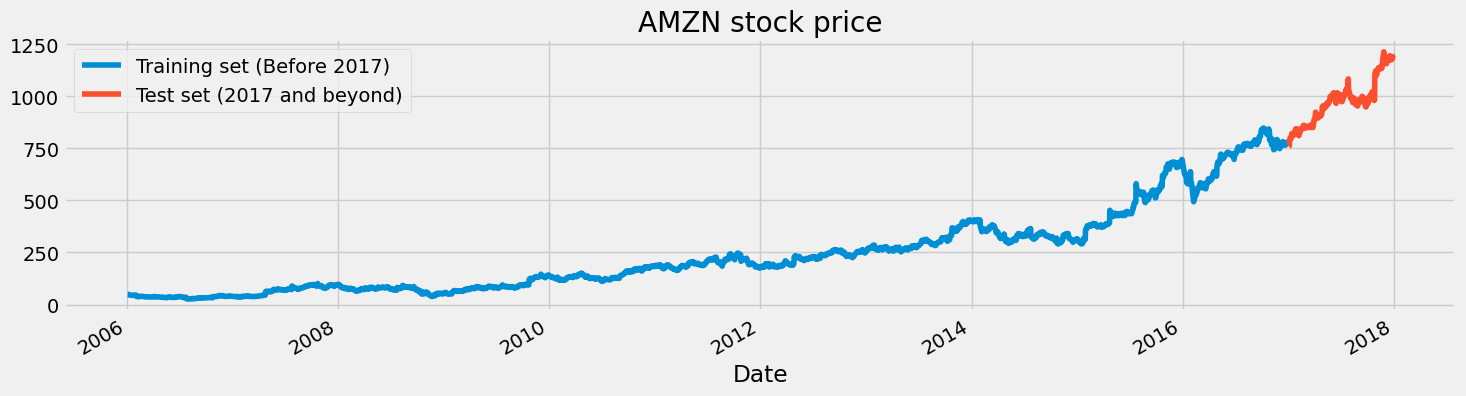

In [3]:
# Checking for missing values
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

# We have chosen 'High' attribute for prices. Let's see what it looks like
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('AMZN stock price')
plt.show()

## Part 3: Preprocessing the Data

In [4]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

## Part 4: Converting Inputs for RNN

In [5]:
# Since LSTMs store long term memory state, we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements
X_train = []
y_train = []
for i in range(60,2768):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping X_train for efficient modelling
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))
print(X_train.shape)

(2708, 60, 1)


## Part 5: RNN Model

In [6]:
# The LSTM architecture
regressor = Sequential()
# First LSTM layer with Dropout regularisation
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
# Second LSTM layer
regressor.add(LSTM(units=5))
# The output layer
regressor.add(Dense(units=1))

# Compiling the RNN
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
# Fitting to the training set
regressor.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0673
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.8793e-04
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.8469e-04
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5635e-04
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9152e-04
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8040e-04
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.4328e-04
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.4397e-04
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.3517e-04


## Part 6: Preparing Data for Testing

In [7]:
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

# Preparing X_test and predicting the prices

X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


## Part 7: Evaluation and Testing

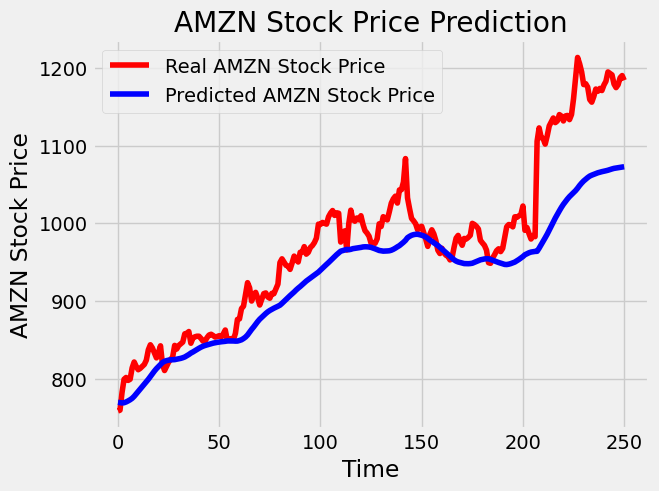

The root mean squared error is 59.76931303252258.


In [8]:
# Some functions to help out with
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Visualizing the results for LSTM
plot_predictions(test_set,predicted_stock_price)

# Evaluating our model
return_rmse(test_set,predicted_stock_price)

***
# Experimentation and Exploration
This section presents our experiments that we conducted to learn more about the RNN architectures and hyperparamteters. Furthermore, we will test diverse combinations in modifying the architecture and fine-tuning the hyperparameters of RNN to see the how those combinations affect the performance of RNN in predicting stock prices. Each experiments are listed below with its corresponding sub-experiments:
- Experiment #1: Other Data Preprocessing Methods
    - Experiment 1.1: z-Score Standardization
    - Experiment 1.2: Log Transformation
- Experiment #2: Adding Layers
    - Experiment 2.1: Adding One Additional LSTM Layer
    - Experiment 2.2: Adding Two Additional LSTM Layers
    - Experiment 2.3: Adding One Additional Dense Layer
- Experiment #3: Changing RNN
    - Experiment 3.1: Using SimpleRNN Layers
    - Experiment 3.2: Using GRU Layers
- Experiment #4: Changing Number of Units
    - Experiment 4.1: Increasing the Number of Units
    - Experiment 4.2: Decreasing the Number of Units
    - Experiment 4.3: Varying Units in Different Layers
- Experiment #5: Changing Learning Rate
    - Experiment 5.1: Increasing the Learning Rate
    - Experiment 5.2: Decreasing the Learning Rate
    - Experiment 5.3: Using a Learning Rate Scheduler
- Experiment #6: Changing Sequence Length
    - Experiment 6.1: Shorter Sequence Length
    - Experiment 6.2: Longer Sequence Length
    - Experiment 6.3: Very Short Sequence Length
- Experiment #7: Different Activation Functions
    - Experiment 7.1: Using `relu` Activation
    - Experiment 7.2: Using `sigmoid` Activation
    - Experiment 7.3: `relu` in the Output Dense Layer
    - Experiment 7.4: `sigmoid` in the Output Dense Layer
- Experiment #8: Adding Dropout to Input or LSTM Layers
    - Experiment 8.1: Adding Dropout After the First LSTM Layer
    - Experiment 8.2: Adding Dropout After the Second LSTM Layer
    - Experiment 8.3: Adding Dropout to Both LSTM Layers
    - Experiment 8.4: Adding Dropout to the Input Sequence 
    - Experiment 8.5: Combining Dropout in LSTM Layers and Input
- Experiment #9: Different Optimizers
    - Experiment 9.1: Using Adam Optimizer
    - Experiment 9.2: Using SGD Optimizer
    - Experiment 9.3: Using Adagrad Optimizer
- Experiment #10: Lagged Features (Feature Engineering)
    - Experiment 10.1: Adding the Previous Day's Price
    - Experiment 10.2: Adding a Moving Average
    - Experiment 10.3: Adding the Price Change
    - Experiment 10.4: Combining Multiple Lagged Features

## Experiment #1: Other Data Preprocessing Methods

This experiment explores other data preprocessing methods to analyze how some preprocessing methods affect the performance of the RNN model. The following sub-experiments are the other preprocessing methods conducted:
- Experiment 1.1 z-Score Standardization
- Experiment 1.2 Log Transformation

### Experiment 1.1: z-Score Standardization
This experiment utilizes the `StandardScaler()` function to conduct the z-score standardization. Z-standardization is a statistical procedure used to make data points from different datasets comparable. In this procedure, each data point is converted into a z-score. A z-score indicates how many standard deviations a data point is from the mean of the dataset. (DATAtab Team, 2025)

(2708, 60, 1)
Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5737
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0930
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0156
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0053
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0048
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0042
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0039
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0039
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0040
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


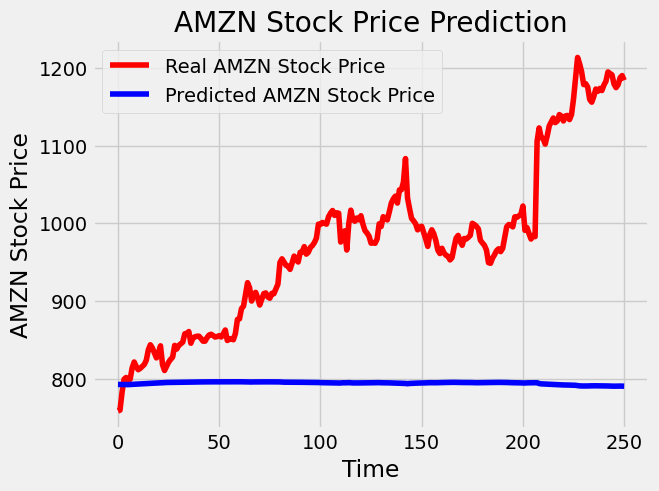

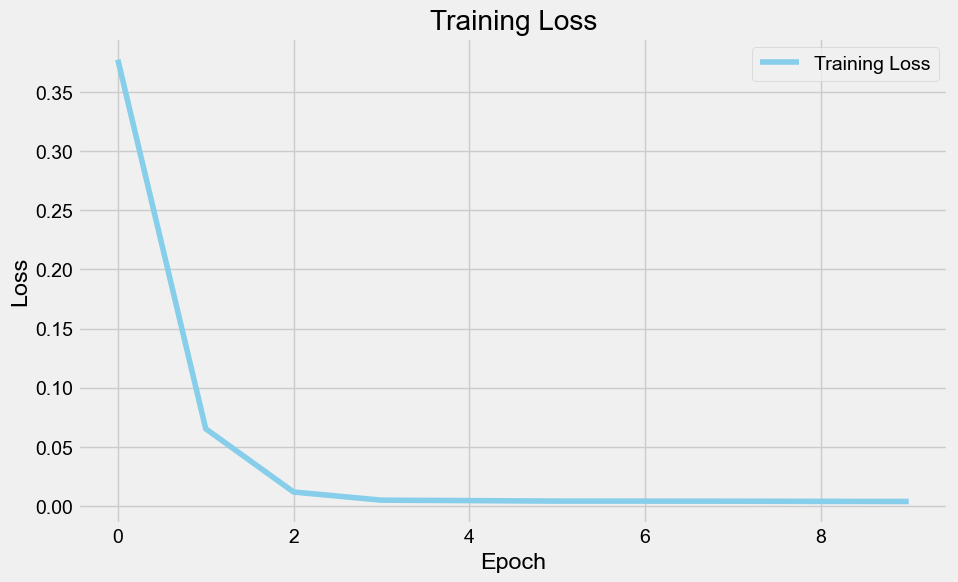

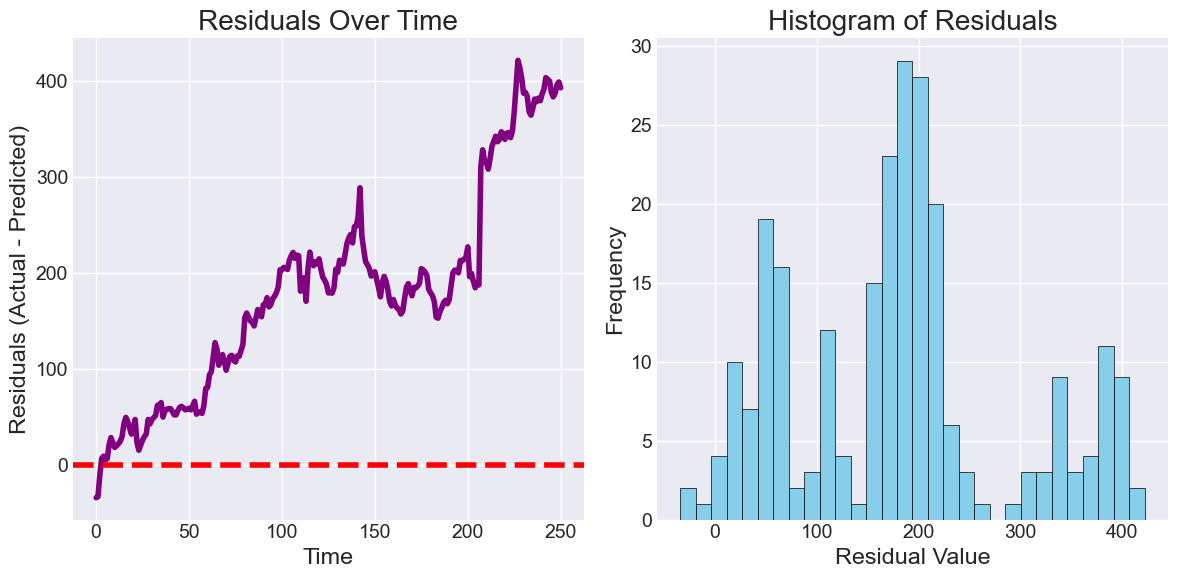

The root mean squared error is 210.39414257921524.


In [9]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

# Preprocessing the data
scaler_standard = StandardScaler() # z-score standardization
training_set_standardized = scaler_standard.fit_transform(training_set) # Initialize and fit the scaler on the training set

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,2768):
    X_train.append(training_set_standardized[i-60:i,0])
    y_train.append(training_set_standardized[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))
print(X_train.shape)

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32)

# Preparing data for testing
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = scaler_standard.transform(inputs) # Apply the same scalar to the test set for consistency and data leakage prevention

X_test = []
for i in range(60,311):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = scaler_standard.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training loss curve
def plot_loss_curve(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curve(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 1.2: Log Transformation
This experiment utilizes the `np.log` function to conduct the log transformation. Log transformation is a data transformation method in which it replaces each variable x with a log(x).  Additionaly, log transformation reduces or removes the skewness of the original data. (Htoon, 2021)

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1980
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0049
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.7446e-04
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.5925e-04
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.3505e-04
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1917e-04
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9873e-04
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2533e-04
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.5925e-04
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.5402e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


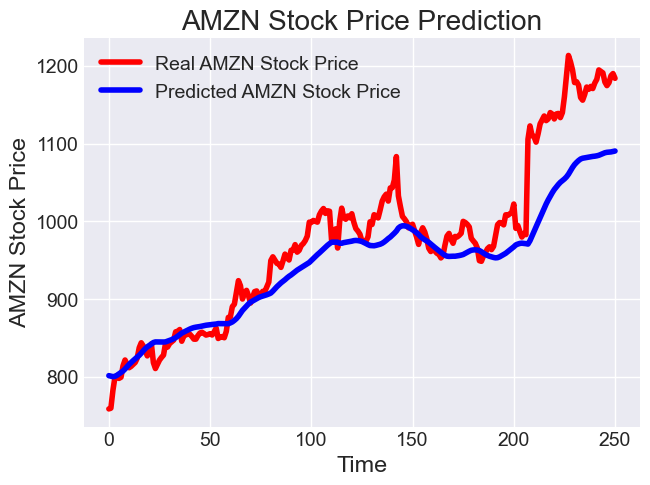

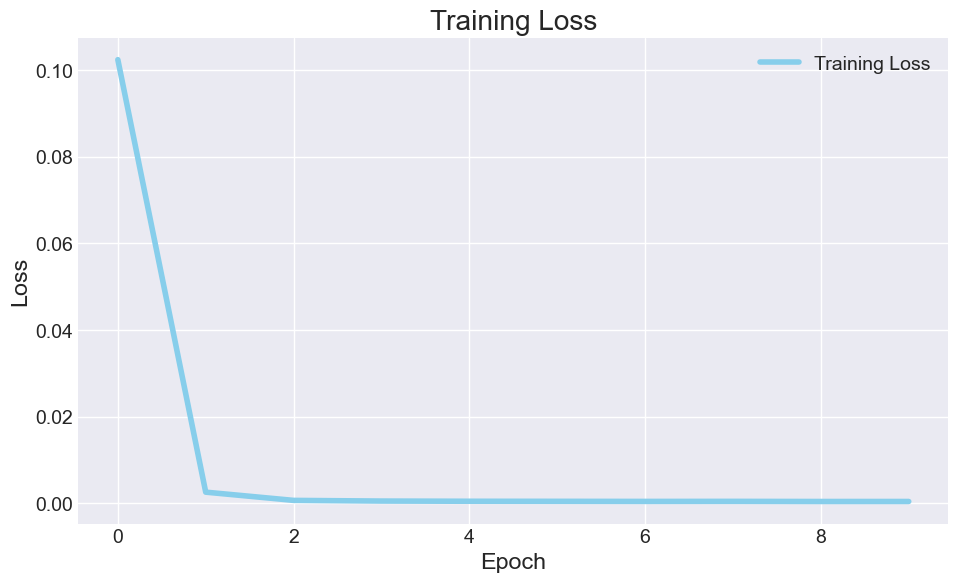

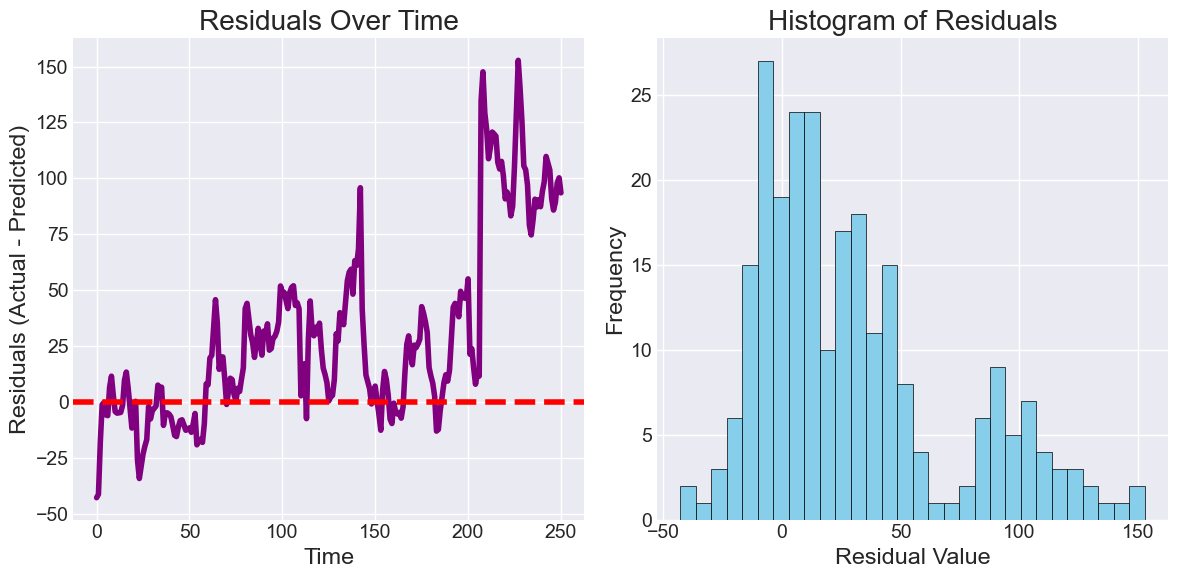

The root mean squared error is 50.75889280307274.


In [10]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

# Preprocessing the data
# Apply log transformation on training set
training_set_log = np.log(training_set)

# Scale the log-transformed data
scaler_log = MinMaxScaler(feature_range=(0, 1))
training_set_scaled_log = scaler_log.fit_transform(training_set_log)

# Converting inputs for RNN
X_train_log = []
y_train_log = []
for i in range(60, len(training_set_scaled_log)):
    X_train_log.append(training_set_scaled_log[i - 60:i, 0])
    y_train_log.append(training_set_scaled_log[i, 0])
X_train_log, y_train_log = np.array(X_train_log), np.array(y_train_log)
X_train_log = np.reshape(X_train_log, (X_train_log.shape[0], X_train_log.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train_log.shape[1],1)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train_log, y_train_log, epochs=10, batch_size=32)

# Preparing data for testing
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs_log = np.log(inputs) # Apply log transformation on testing set
inputs_scaled_log = scaler_log.transform(inputs_log) # Scale the log-transformed data

X_test = []
for i in range(60,311):
    X_test.append(inputs_scaled_log[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = scaler_log.inverse_transform(predicted_stock_price) # Inverse transform the scaling
predicted_stock_price = np.exp(predicted_stock_price) # Inverse transform the log

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training loss curve
def plot_loss_curve(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curve(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #2: Adding Layers

This experiment explores how adding a certain amount of layers to the RNN model would affect the model's performance. The following sub-experiments are the additional recurrent layers conducted:
- Experiment 2.1: Adding One Additional LSTM Layer
- Experiment 2.2: Adding Two Additional LSTM Layers
- Experiment 2.3: Adding One Additional Dense Layer

### Experiment 2.1: Adding One Additional LSTM Layer
Adding one more LSTM layer can potentially allow the model to learn more complex temporal dependencies. The `return_sequence=True` in the second layer ensures that the output sequence is passed to the third LSTM layer. We also modified the data splitting since we want to add a validation set to see how the model will perform on unseen data during training.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0055 - val_loss: 0.0358
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.1598e-04 - val_loss: 0.0093
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.8993e-04 - val_loss: 0.0026
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 4.6395e-04 - val_loss: 0.0016
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 5.0866e-04 - val_loss: 0.0016
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.8282e-04 - val_loss: 0.0024
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.6730e-04 - val_loss: 0.0044
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.5036e-04 - val_loss: 0.0014
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.2641e-04 - val_loss: 0.0085
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4.6127e-04 - val_loss: 0.0011
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


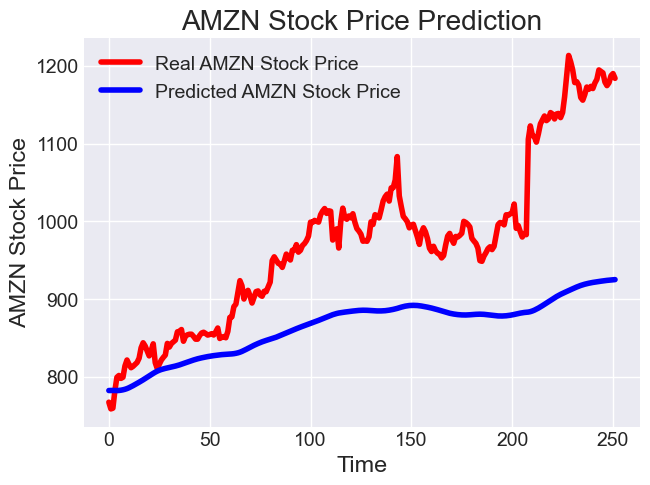

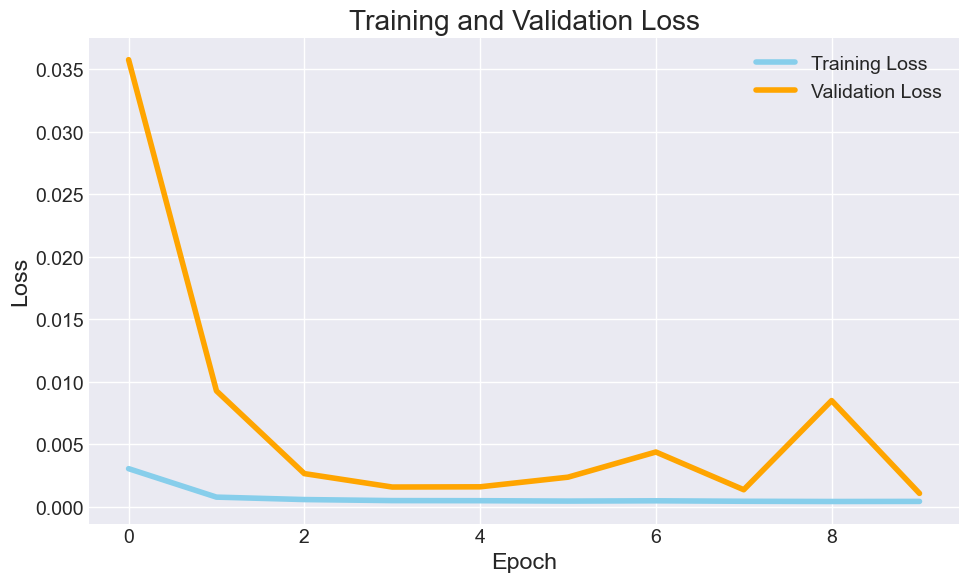

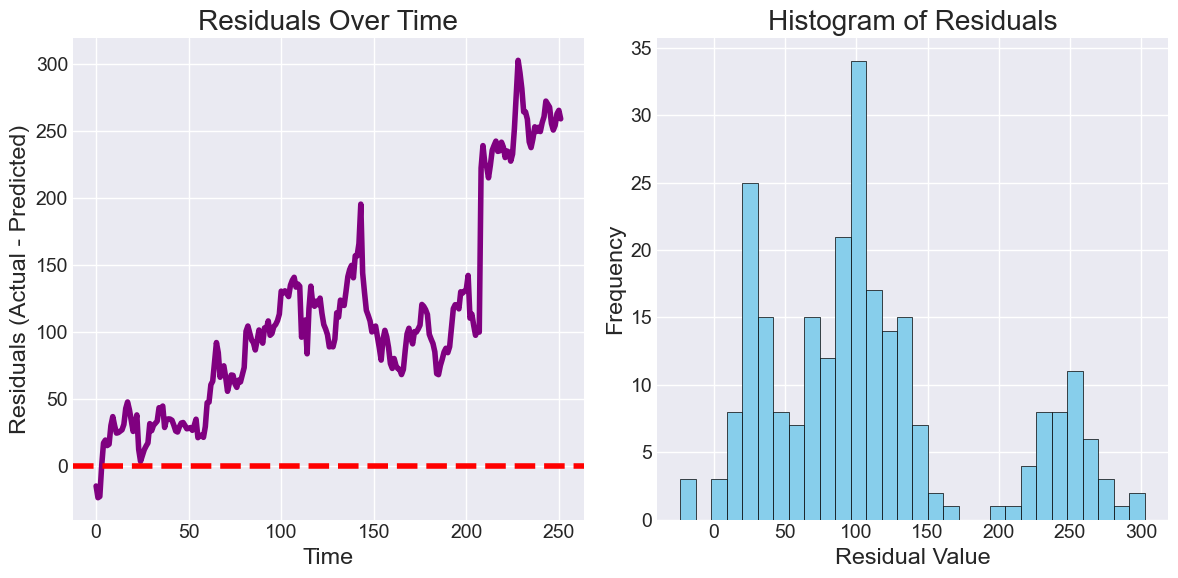

The root mean squared error is 132.7860207480221.


In [11]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values # Includes validation and test

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) # 50% for validation, 50% for test
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5, return_sequences=True)) # Added a second LSTM layer with return_sequences=TRUE
regressor.add(LSTM(units=5)) # Added a thrid LSTM layer
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 2.2: Adding Two Additional LSTM Layers
Increasing the depth of the network further might enable the model to capture hierarchical patterns in the stock price data.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0663 - val_loss: 0.1657
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0028 - val_loss: 0.0611
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0021 - val_loss: 0.0511
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0017 - val_loss: 0.0247
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0014 - val_loss: 0.0164
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0012 - val_loss: 0.0167
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0011 - val_loss: 0.0104
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0011 - val_loss: 0.0060
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0011 - val_loss: 0.0055
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 9.0589e-04 - val_loss: 0.0047
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


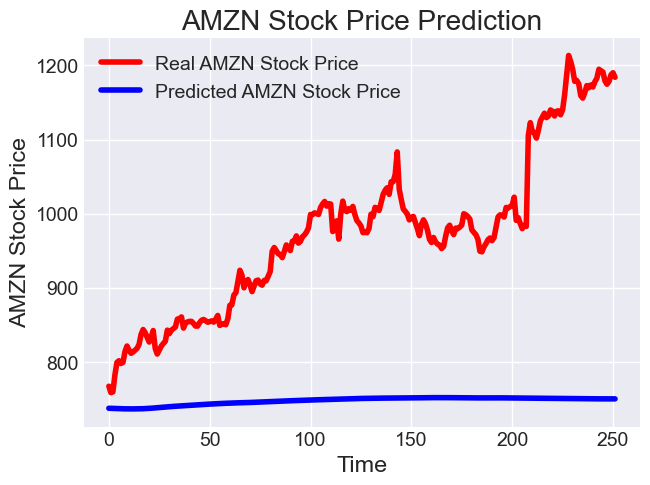

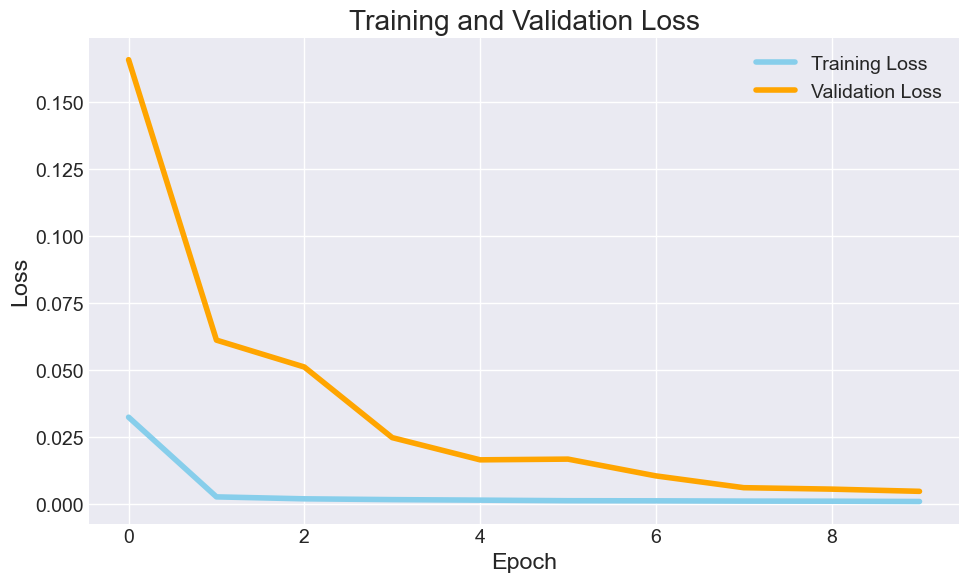

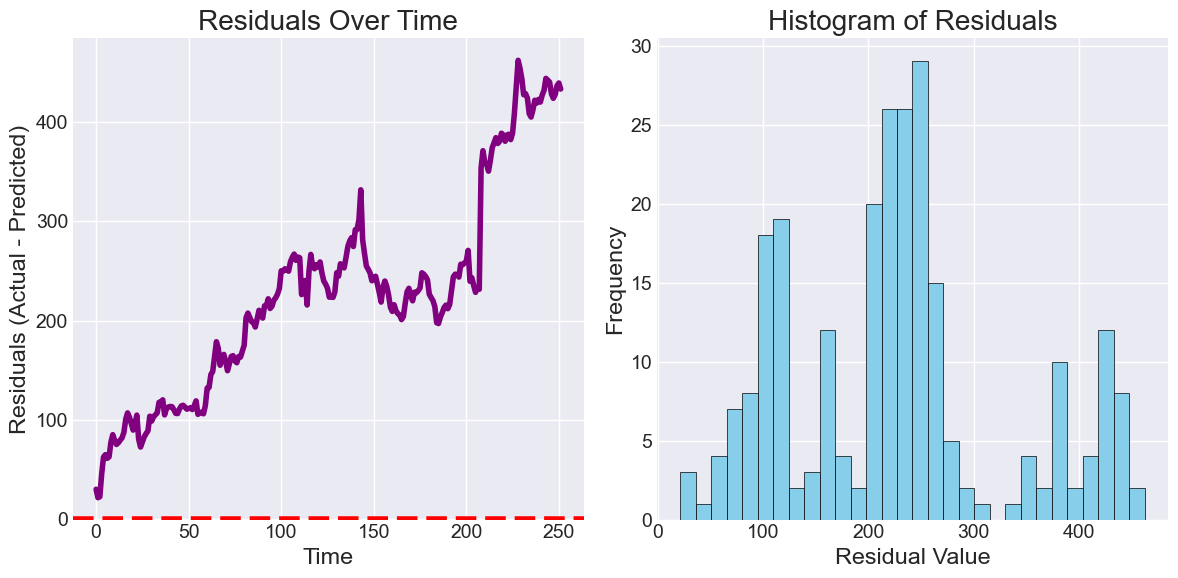

The root mean squared error is 249.09886735975306.


In [12]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5, return_sequences=True)) # Second LSTM layer with return_sequences=TRUE
regressor.add(LSTM(units=5, return_sequences=True)) # Third LSTM layer with return_sequences=TRUE
regressor.add(LSTM(units=5)) # Added a fourth LSTM layer
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 2.3 Adding One Additional Dense Layer
Adding a dense layer after the LSTM layers can provide an extra level of feature transformation before the final prediction. We set the units of the added dense layer to 5.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0589 - val_loss: 0.0880
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.7599e-04 - val_loss: 0.0119
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7158e-04 - val_loss: 0.0060
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.8109e-04 - val_loss: 0.0035
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.8162e-04 - val_loss: 0.0045
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.6943e-04 - val_loss: 0.0013
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5006e-04 - val_loss: 0.0033
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.2204e-04 - val_loss: 0.0020
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.2758e-04 - val_loss: 0.0016
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.8761e-04 - val_loss: 7.5200e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


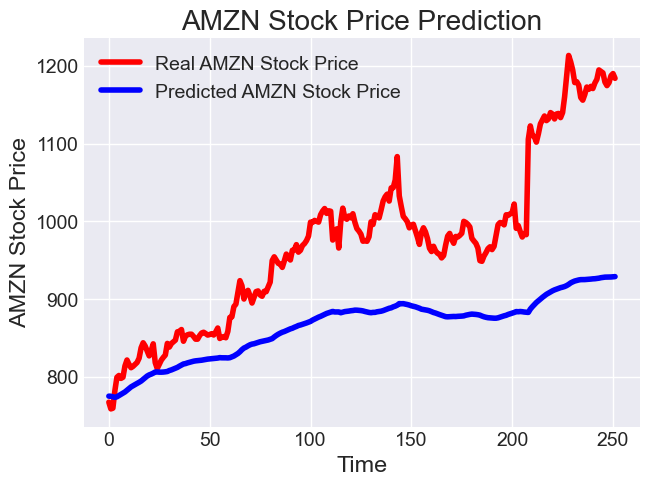

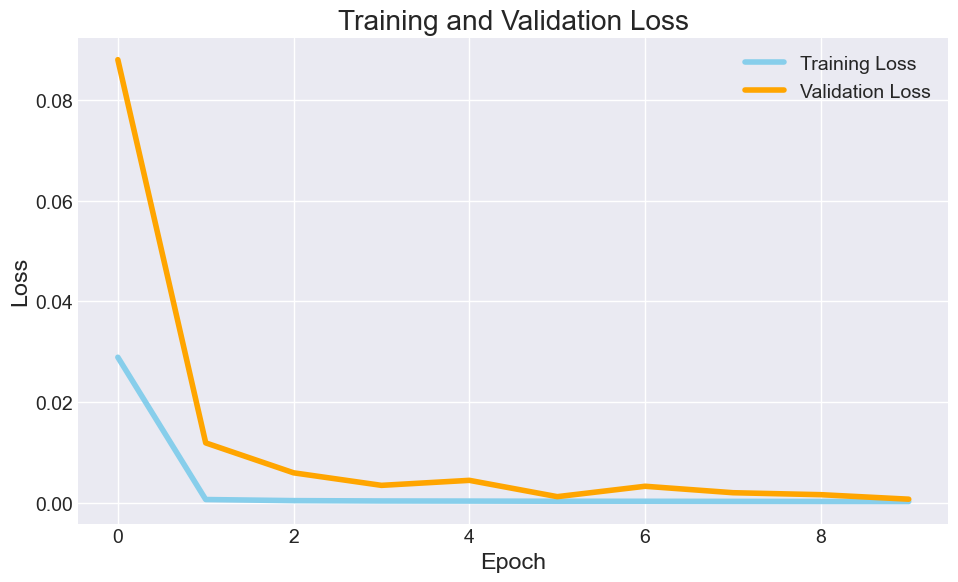

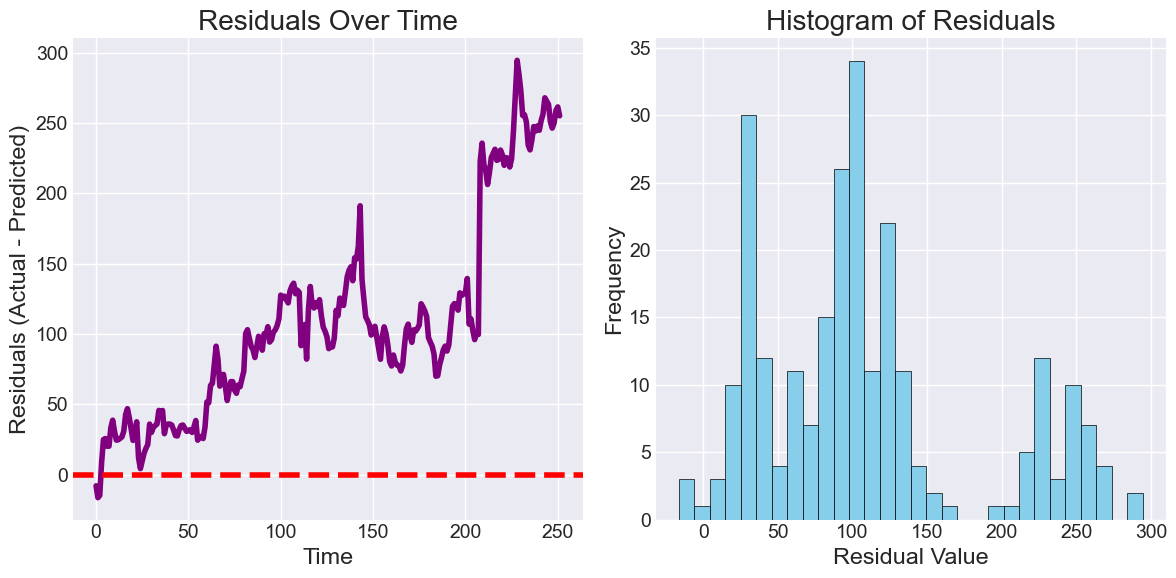

The root mean squared error is 130.4069284682745.


In [13]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=5)) # Added one dense layer with 5 units
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #3: Changing RNN

This experiment explores the effects of changing the type of RNN model in predicting the stock prices. The following sub-experiments are the different types of RNN conducted:
- Experiment 3.1: Using SimpleRNN Layers
- Experiment 3.2: Using GRU Layers

### Experiment 3.1 Using SimpleRNN Layers
SimpleRNN is the recurrent layer object in Keras which is the basic recurrent neural network (Batsuuri, 2023).

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0496 - val_loss: 0.3792
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0085 - val_loss: 0.1018
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0517
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.4973e-04 - val_loss: 0.0391
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.9708e-04 - val_loss: 0.0277
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.6722e-04 - val_loss: 0.0215
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.0949e-04 - val_loss: 0.0194
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.5359e-04 - val_loss: 0.0226
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.0623e-04 - val_loss: 0.0188
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.6371e-04 - val_loss: 0.0144
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


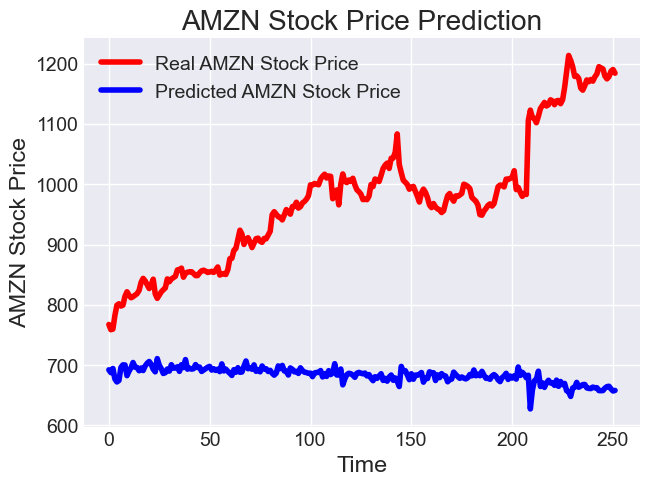

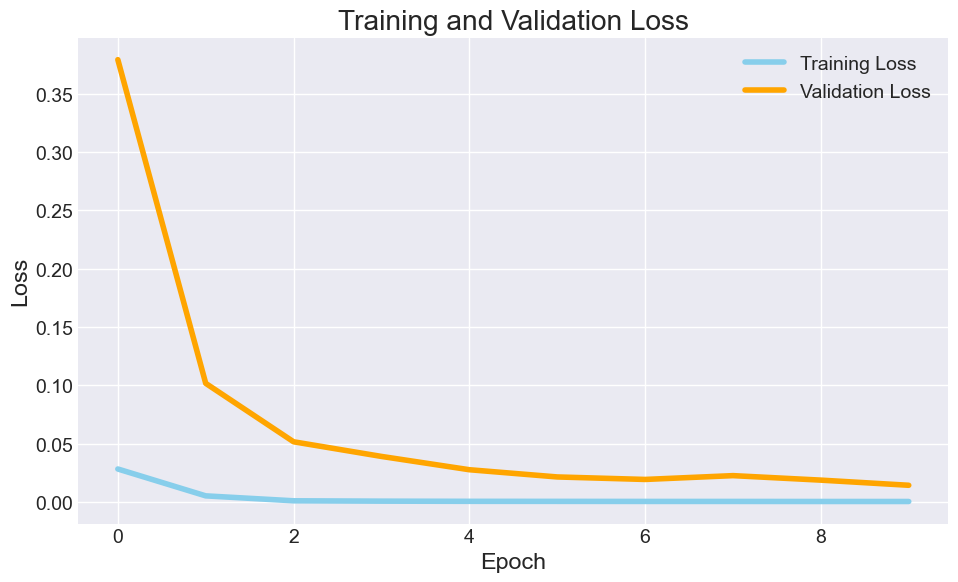

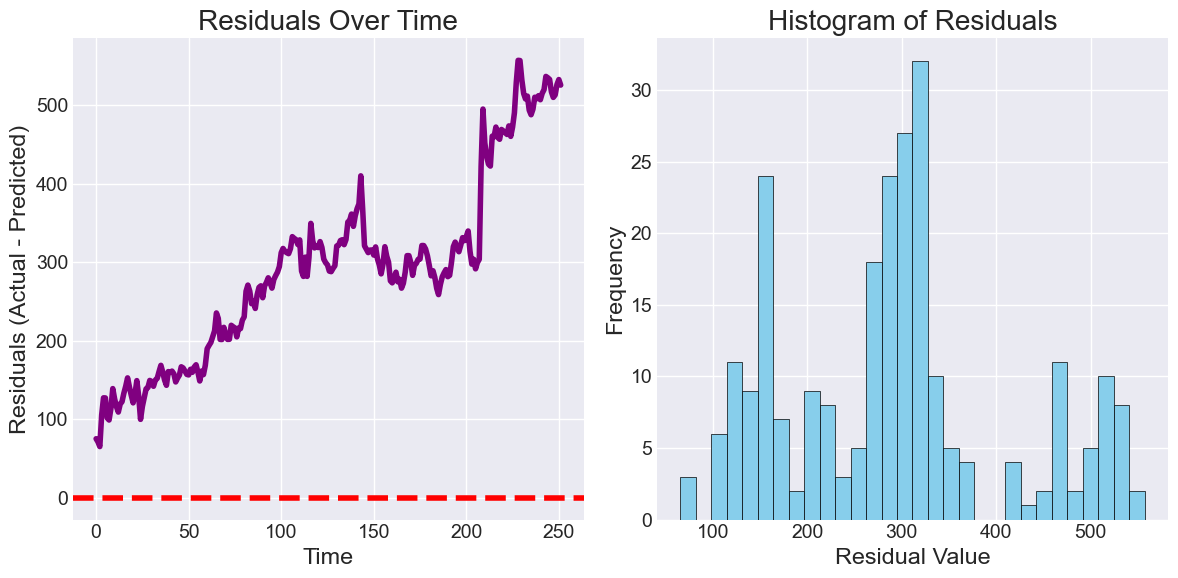

The root mean squared error is 313.35243450567725.


In [14]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (SimpleRNN)
regressor = Sequential()
regressor.add(SimpleRNN(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  # Replaced LSTM with SimpleRNN
regressor.add(SimpleRNN(units=5)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 3.2: Using GRU Layers
GRUs was introduced by Kyunghyun Cho et al. in 2014. GRUs are like LSTM but with gating mechanism, which sometimes can be more efficient to train.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0675 - val_loss: 0.3058
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0097 - val_loss: 0.0148
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.2500e-04 - val_loss: 0.0088
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.9303e-04 - val_loss: 0.0059
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.9421e-04 - val_loss: 0.0049
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.6196e-04 - val_loss: 0.0066
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.1180e-04 - val_loss: 0.0036
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.0626e-04 - val_loss: 0.0077
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 2.0446e-04 - val_loss: 0.0074
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.9683e-04 - val_loss: 0.0031
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


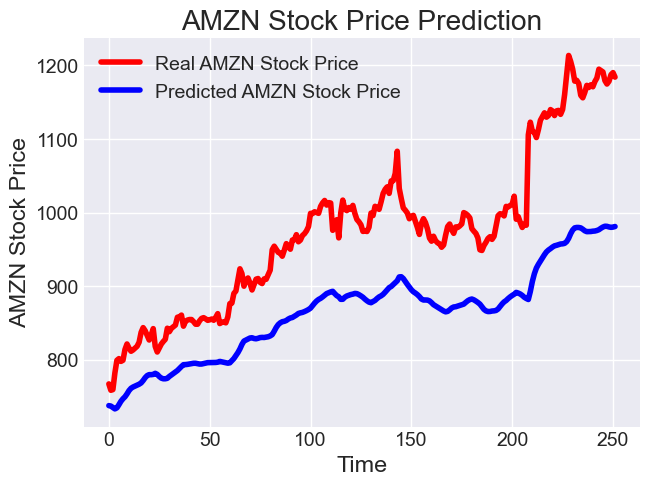

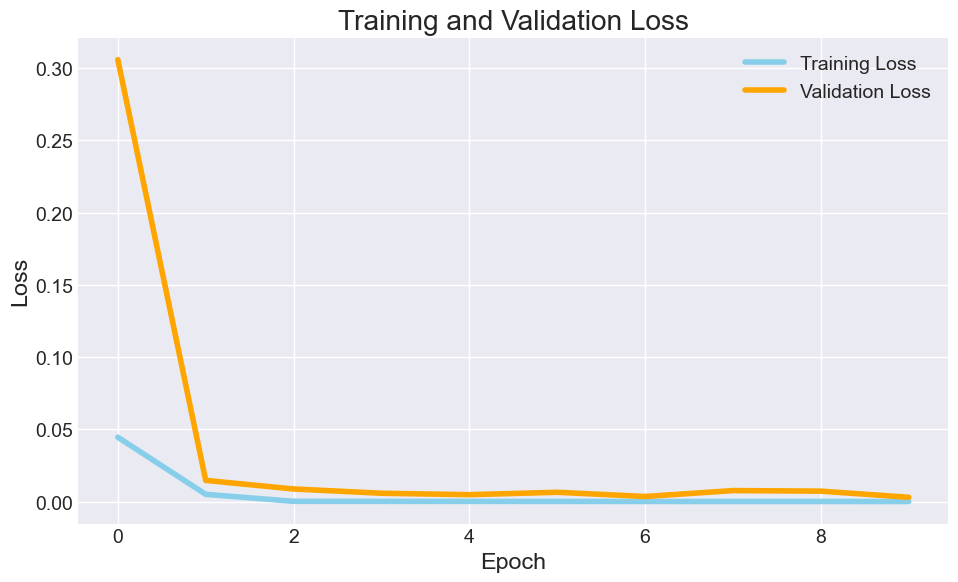

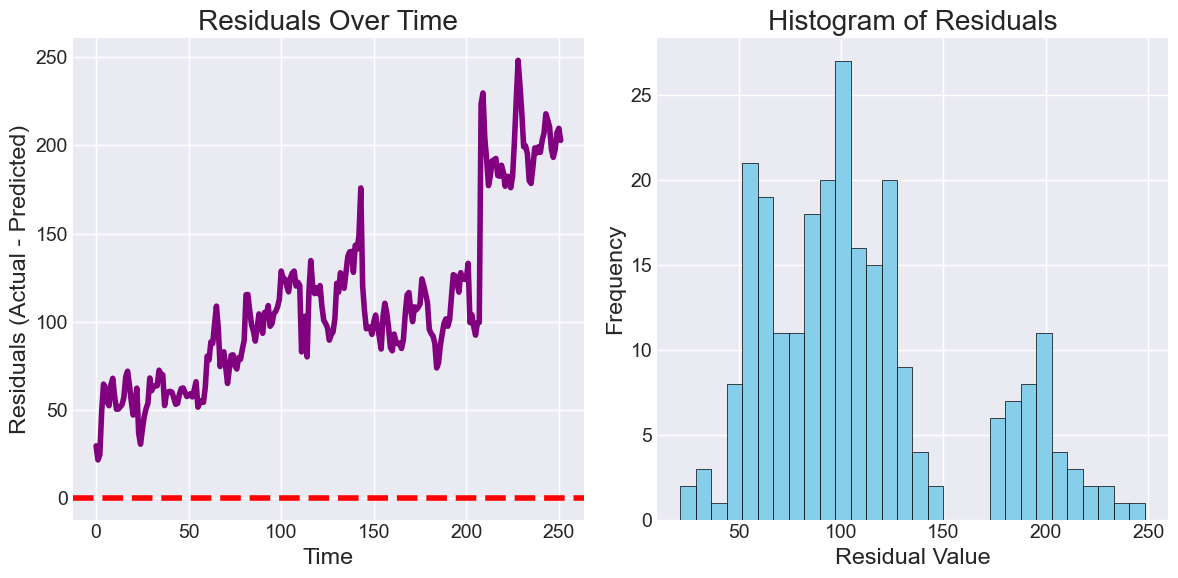

The root mean squared error is 119.7939122350187.


In [15]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (GRU)
regressor = Sequential()
regressor.add(GRU(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  # Replaced LSTM with GRU
regressor.add(GRU(units=5)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #4: Changing Number of Units

This experiment explores how changing the number of units in each recurrent layer affects the model's ability to learn complex patterns from the stock price data. The following sub-experiments are the different number of units conducted:
- Experiment 4.1: Increasing the Number of Units
- Experiment 4.2: Decreasing the Number of Units
- Experiment 4.3: Varying Units in Different Layers

### Experiment 4.1: Increasing the Number of Units
This sub-experiment increased the number of units of both LSTM layers to 20. Increasing the number of units in each LSTM layer increases the dimensionality of the hidden state

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0158 - val_loss: 0.0109
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.2173e-04 - val_loss: 9.1726e-04
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.9450e-04 - val_loss: 0.0196
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.0025e-04 - val_loss: 0.0065
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.8298e-04 - val_loss: 0.0058
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.9320e-04 - val_loss: 0.0029
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.4211e-04 - val_loss: 0.0034
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.7978e-04 - val_loss: 0.0019
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1804e-04 - val_loss: 8.2310e-04
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.1070e-04 - val_loss: 0.0029
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


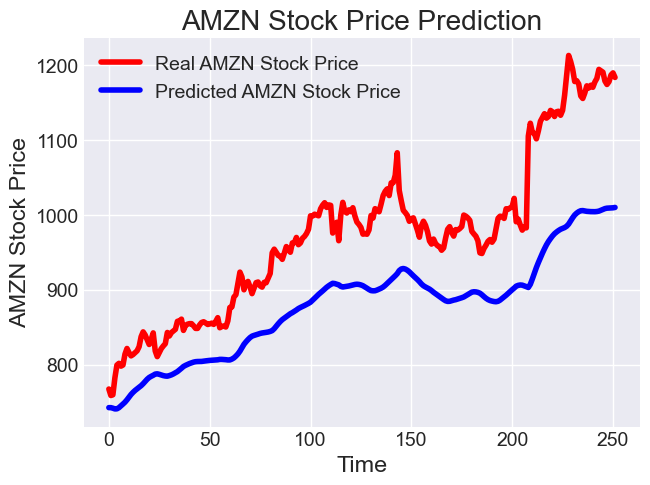

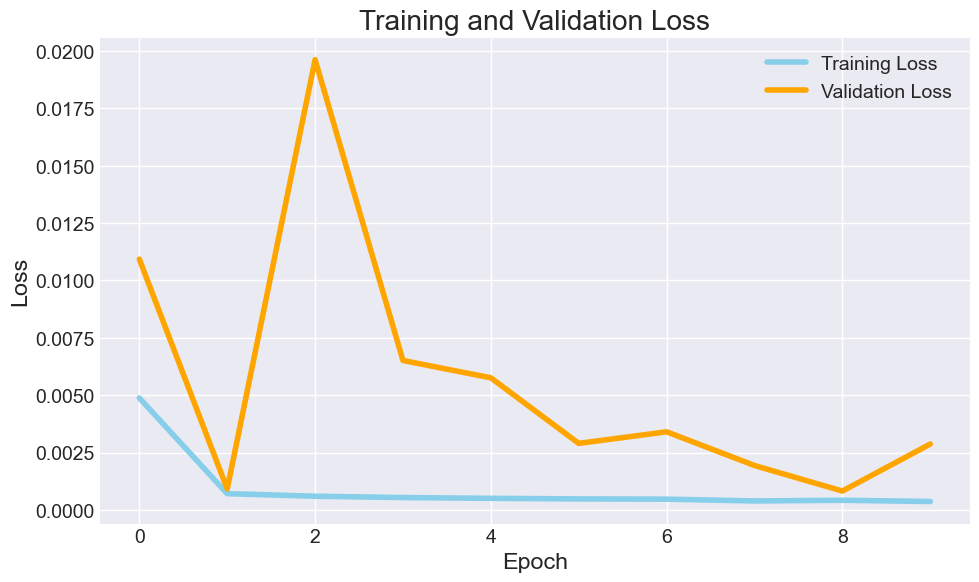

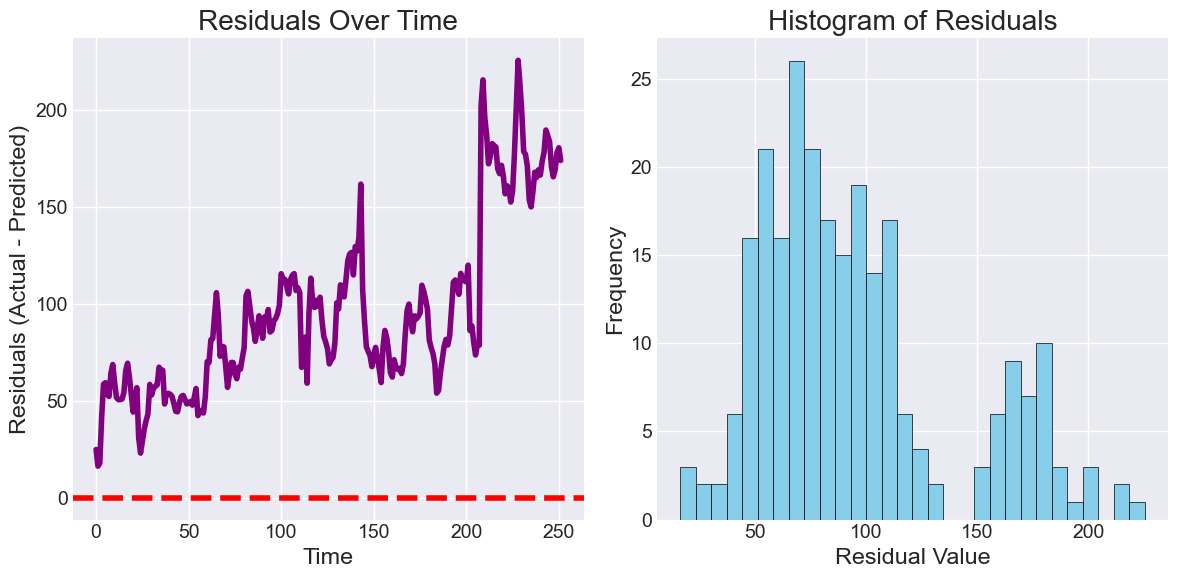

The root mean squared error is 104.97495166928077.


In [16]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=20, return_sequences=True, input_shape=(X_train.shape[1],1)))  # Increased units to 20 for both LSTM layers
regressor.add(LSTM(units=20)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 4.2: Decreasing the Number of Units
This sub-experiment decreased the number of units of both LSTM layers to 2. Decreasing the number of units reduces the model's capacity.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1108 - val_loss: 0.8490
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0452 - val_loss: 0.6049
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0242 - val_loss: 0.4139
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0099 - val_loss: 0.2829
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0054 - val_loss: 0.1883
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0023 - val_loss: 0.1062
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0610
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - val_loss: 0.0421
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.9353e-04 - val_loss: 0.0287
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.9705e-04 - val_loss: 0.0235
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


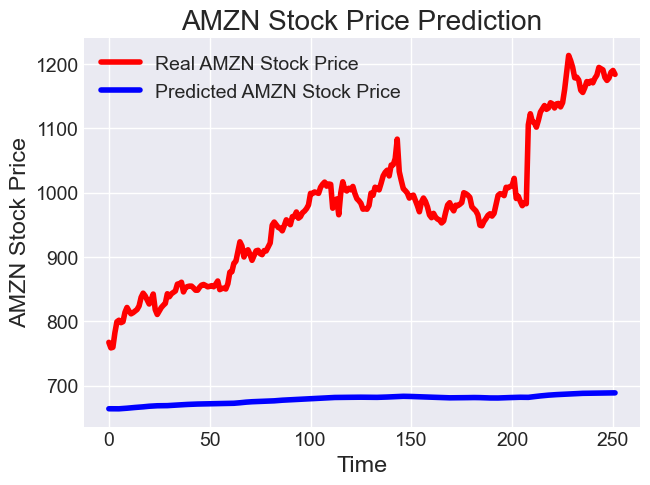

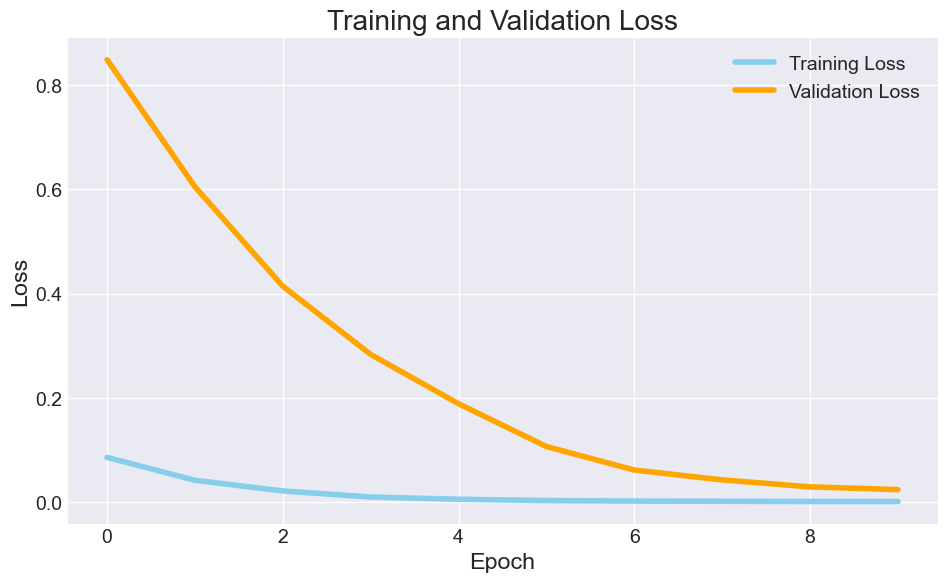

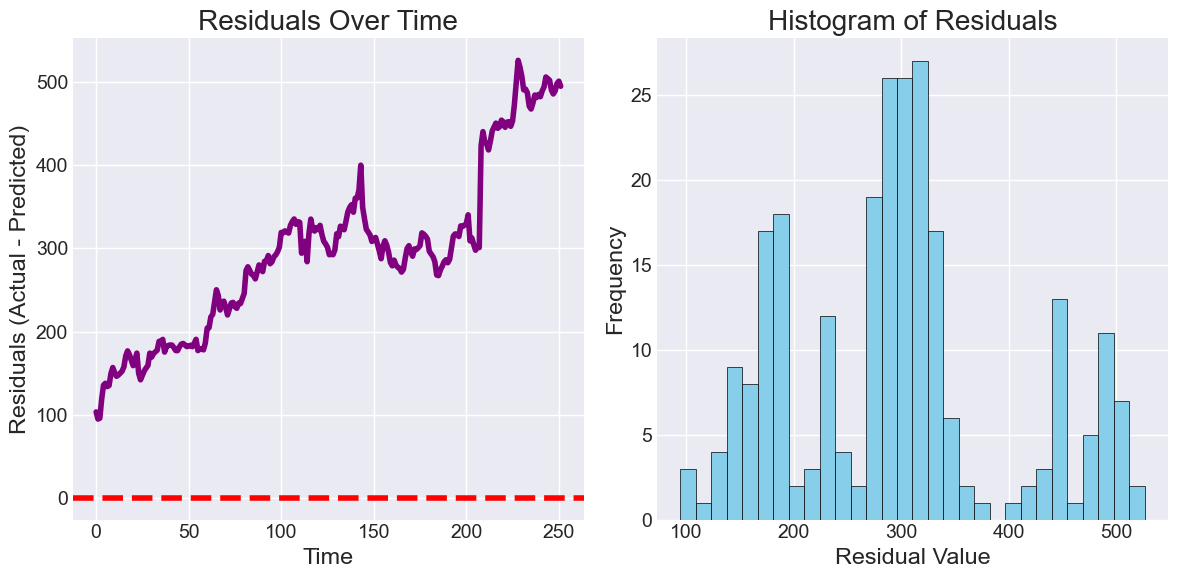

The root mean squared error is 312.2710645511186.


In [17]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=2, return_sequences=True, input_shape=(X_train.shape[1],1)))  # Decreased units to 2 for both LSTM layers
regressor.add(LSTM(units=2)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 4.3: Varying Units in Different Layers
This sub-experiment sets the unit of first LSTM layer to 10 while the units of second LSTM layer to 3. Experimenting with different numbers of units in different layers can explore whether certain layers benefit from higher or lower capacity.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0143 - val_loss: 0.0414
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.3935e-04 - val_loss: 0.0137
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.0053e-04 - val_loss: 0.0131
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1996e-04 - val_loss: 0.0095
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.5659e-04 - val_loss: 0.0078
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.1991e-04 - val_loss: 0.0058
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.6824e-04 - val_loss: 0.0026
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8750e-04 - val_loss: 0.0029
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.9837e-04 - val_loss: 0.0020
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8610e-04 - val_loss: 0.0033
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


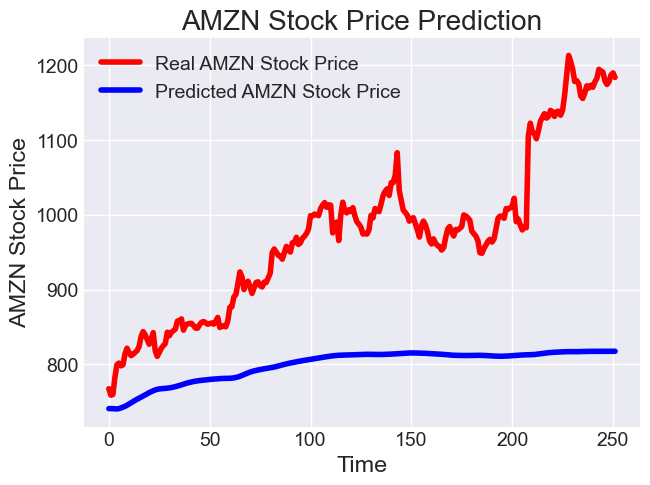

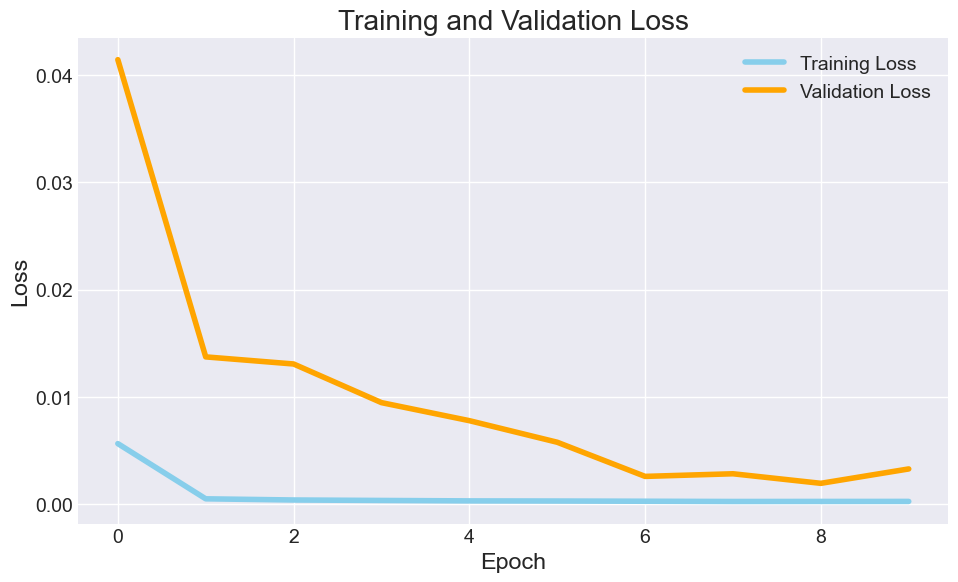

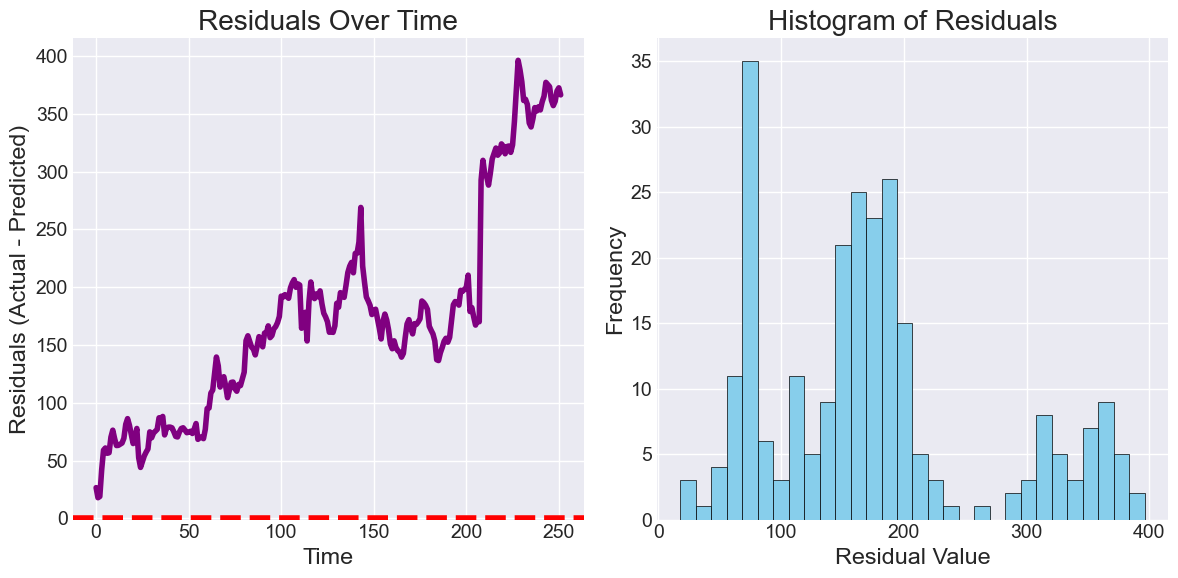

The root mean squared error is 197.02891089598572.


In [18]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=10, return_sequences=True, input_shape=(X_train.shape[1],1)))  # Set units to 10
regressor.add(LSTM(units=3)) # Set units to 3
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #5: Changing the Learning Rate

This experiment explores how changing the learning rate affects the model's performance and training. The following sub-experiments are the different learning rates conducted:
- Experiment 5.1: Increasing the Learning Rate
- Experiment 5.2: Decreasing the Learning Rate
- Experiment 5.3: Using a Learning Rate Scheduler

### Experiment 5.1: Increasing the Learning Rate
This sub-experiment sets the learning rate to 0.01. A higher learning rate can make the optimization process converge faster initially.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0208 - val_loss: 0.0158
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - val_loss: 0.0067
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0198
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0046
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0094
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.9012e-04 - val_loss: 8.6804e-04
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.0602e-04 - val_loss: 0.0110
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.5138e-04 - val_loss: 0.0014
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1628e-04 - val_loss: 0.0020
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.4671e-04 - val_loss: 0.0015
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


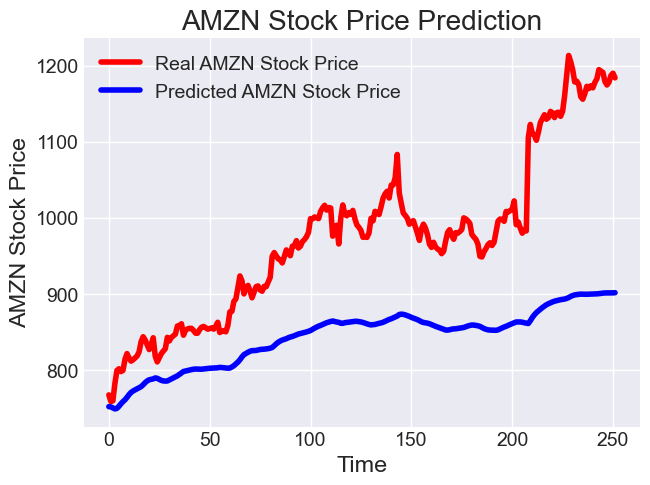

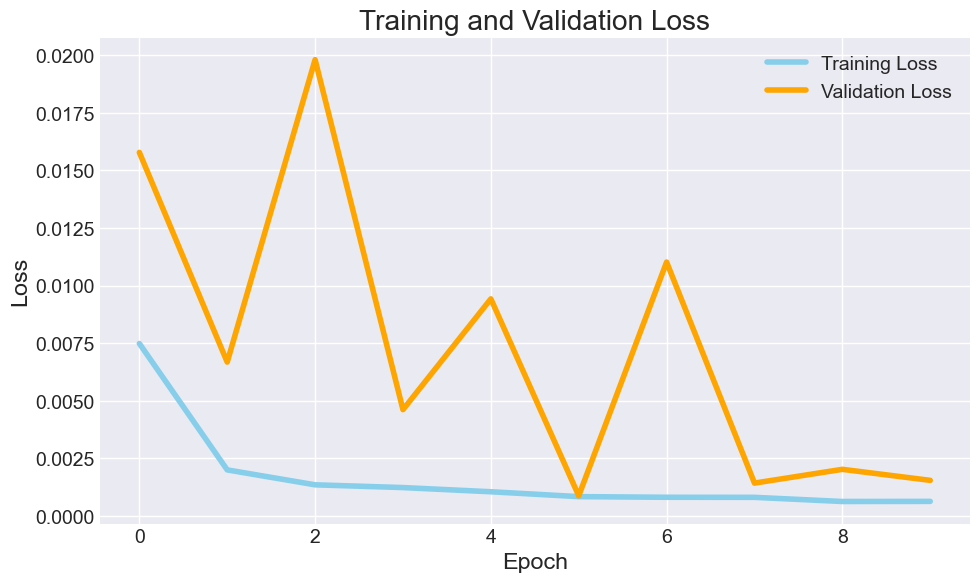

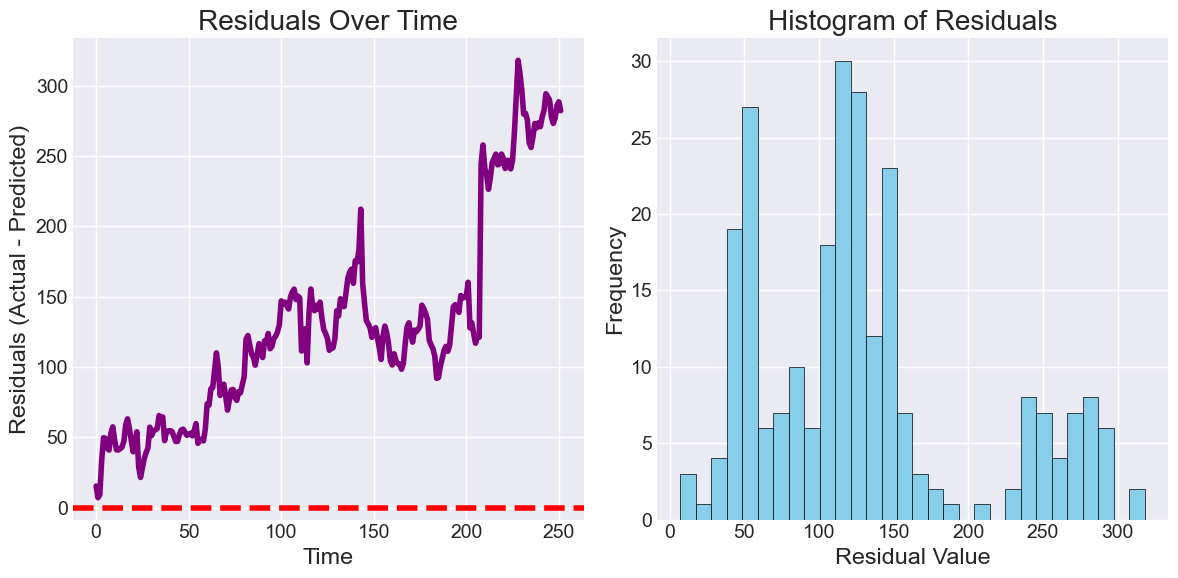

The root mean squared error is 149.2481370393941.


In [19]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1))

optimizer = RMSprop(learning_rate=0.01) # Increased learning rate
regressor.compile(optimizer=optimizer,loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 5.2: Decreasing the Learning Rate
This sub-experiment sets the learning rate to 0.0001. A lower learning rate can make the optimization process more stable and help it converge to a finer minimum.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2643 - val_loss: 1.8174
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1832 - val_loss: 1.5016
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1230 - val_loss: 1.1831
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0734 - val_loss: 0.8991
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0540 - val_loss: 0.6885
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0383 - val_loss: 0.5393
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0298 - val_loss: 0.4382
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0233 - val_loss: 0.3644
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0184 - val_loss: 0.3041
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0107 - val_loss: 0.2470
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


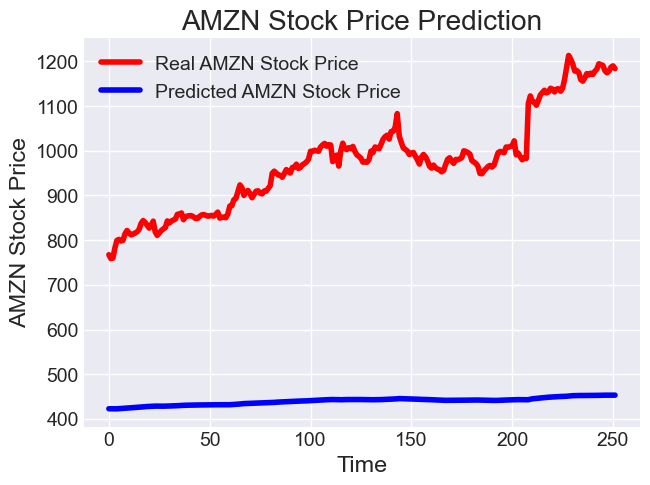

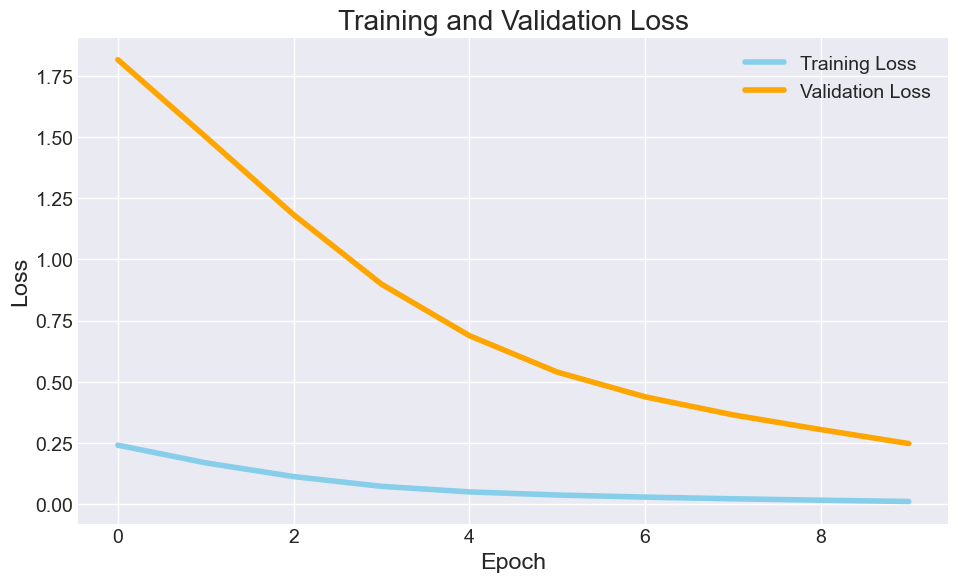

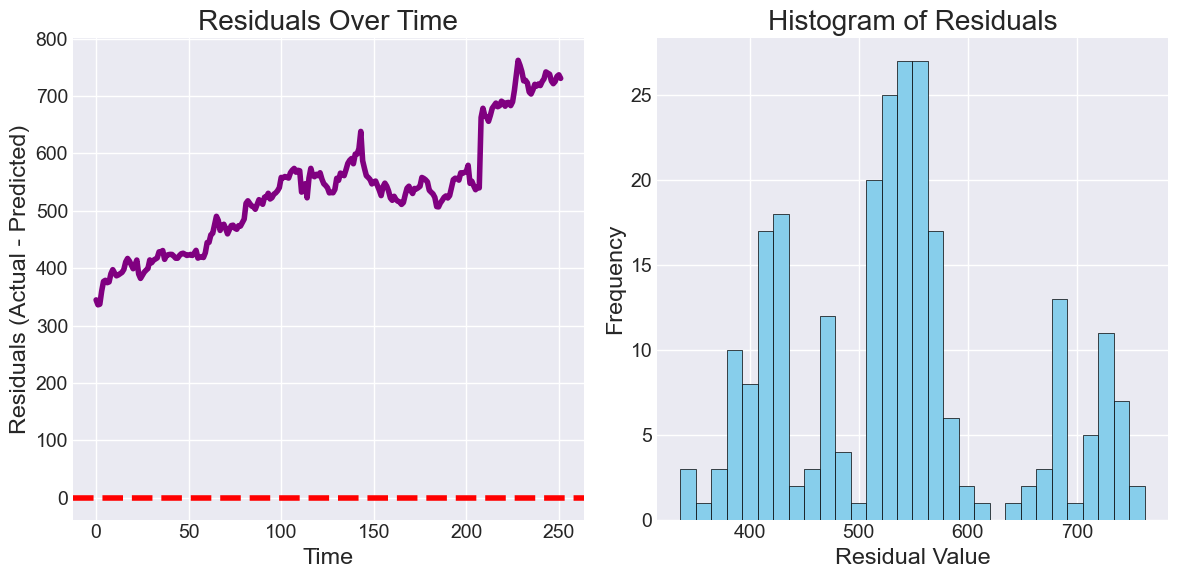

The root mean squared error is 543.5037825316612.


In [20]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1))

optimizer = RMSprop(learning_rate=0.0001) # Decreased learning rate
regressor.compile(optimizer=optimizer,loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 5.3: Using a Learning Rate Scheduler
Keras provides callbacks to manage the learning rate duing training in which we will use `ReduceLROnPlateau` callback. This specific callback was used for this experiment since it does not require manually designing a complex epoch-based schedule. Learning rate schedulers can combine the benefits of higher and lower learning rates during different phases of training.

Epoch 1/50


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1627 - val_loss: 0.6107 - learning_rate: 0.0010
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0249 - val_loss: 0.1599 - learning_rate: 0.0010
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020 - val_loss: 0.0675 - learning_rate: 0.0010
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.4471e-04 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.3965e-04 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7510e-04 - val_loss: 0.0177 - learning_rate: 0.0010
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.7496e-04 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.6618e-04 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.1937e-04 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 

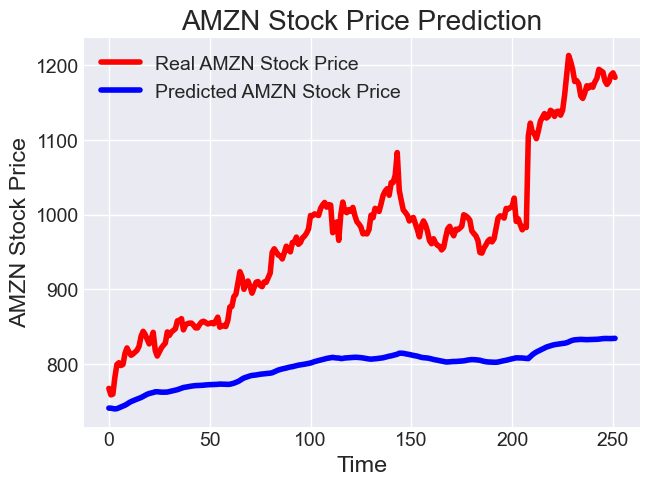

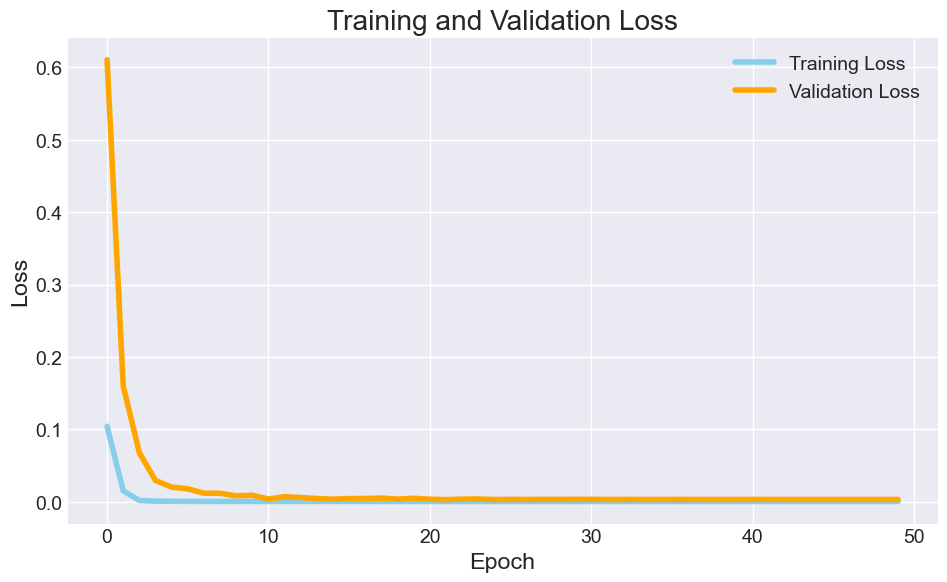

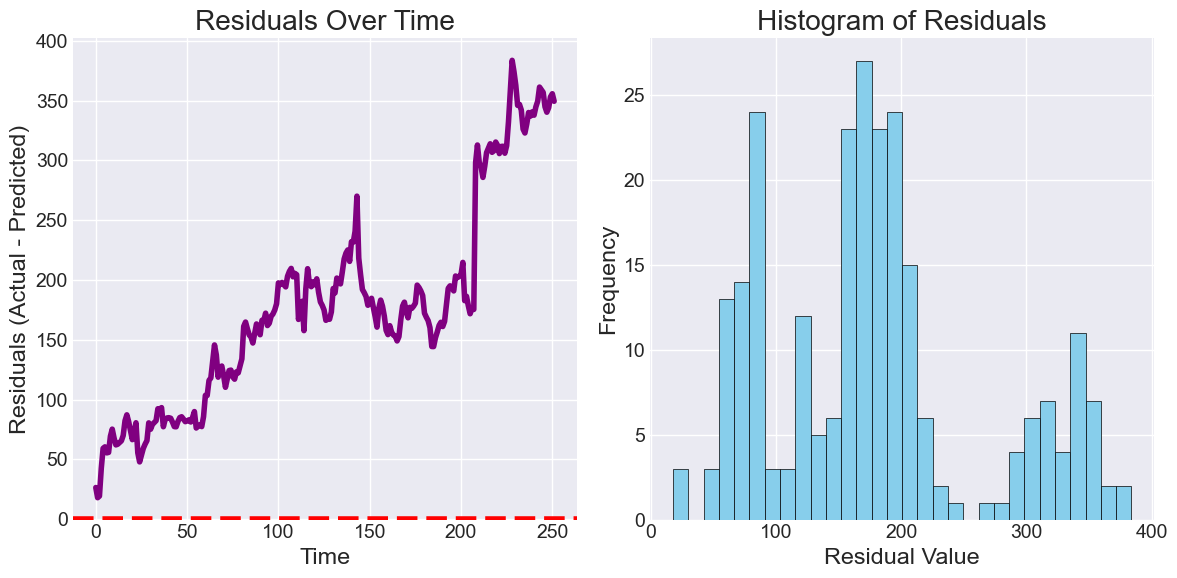

The root mean squared error is 196.7298132383553.


In [21]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1))

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1, mode='min', min_lr=0.00001) # Define the ReduceLROnPlateau callback
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[lr_scheduler])   # Pass the callback to the fit method, also added more epochs to see the effect

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #6: Changing Sequence Length

This experiment explores how changing the sequence length affects the model's ability to predict future stock prices. The following sub-experiments are the different number of sequence length conducted:
- Experiment 6.1: Shorter Sequence Length
- Experiment 6.2: Longer Sequence Length
- Experiment 6.3: Very Short Sequence Length

### Experiment 6.1: Shorter Sequence Length
This sub-experiment sets the sequence length to 20. Shorter sequences might allow the model to react more quickly to recent market changes and short-term fluctuations.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0766 - val_loss: 0.2179
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - val_loss: 0.0703
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - val_loss: 0.0278
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.2498e-04 - val_loss: 0.0221
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2882e-04 - val_loss: 0.0147
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3990e-04 - val_loss: 0.0108
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5898e-04 - val_loss: 0.0084
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5508e-04 - val_loss: 0.0074
Epoch 9/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1404e-04 - val_loss: 0.0061
Epoch 10/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1755e-04 - val_loss: 0.0042
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


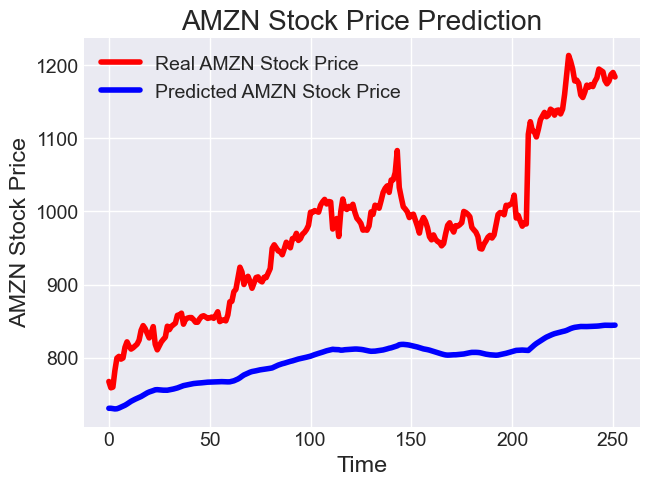

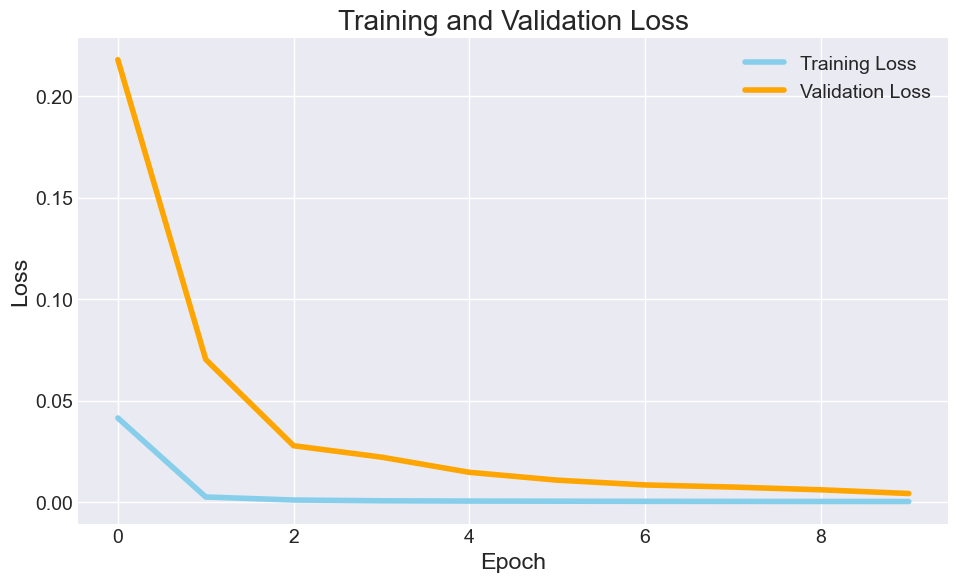

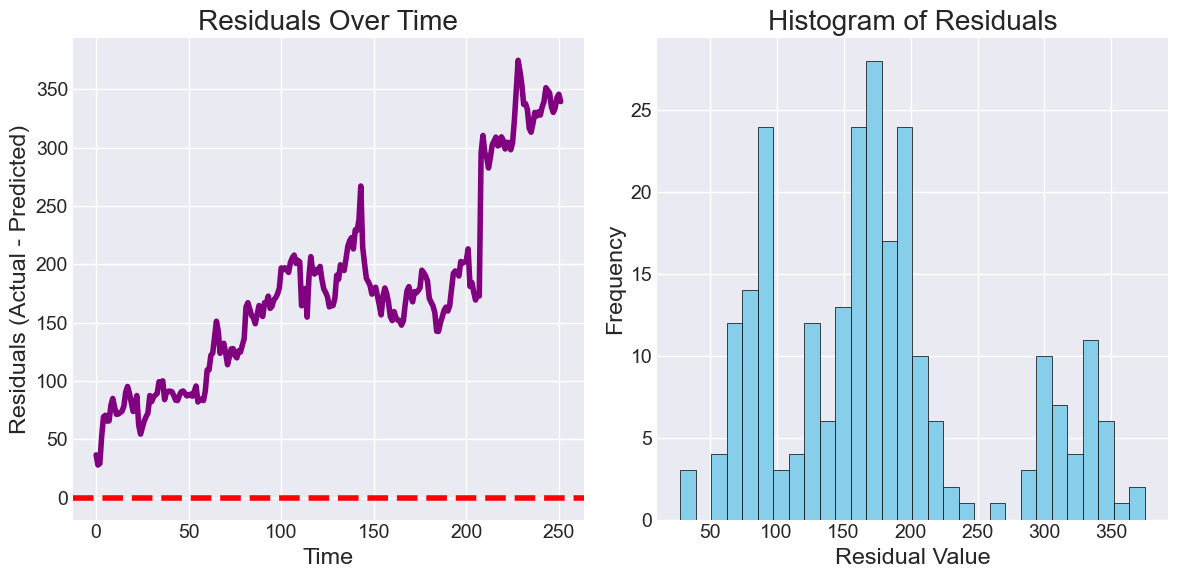

The root mean squared error is 194.5301170086842.


In [22]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(20,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-20:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(20, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 20:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 20:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(20,len(inputs)):
    X_test.append(inputs[i-20:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 6.2: Longer Sequence Length
This sub-experiment sets the sequence length to 120. Longer sequences provide the model with more historical information, potentially allowing it to learn longer-term patterns and dependencies. 

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0423 - val_loss: 0.0527
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 6.1413e-04 - val_loss: 0.0172
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 5.4029e-04 - val_loss: 0.0074
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 5.0274e-04 - val_loss: 0.0047
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.7284e-04 - val_loss: 0.0078
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 4.2309e-04 - val_loss: 0.0018
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.4418e-04 - val_loss: 0.0012
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.1445e-04 - val_loss: 9.6672e-04
Epoch 9/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.2627e-04 - val_loss: 0.0027
Epoch 10/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.3790e-04 - val_loss: 8.2210e-04
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


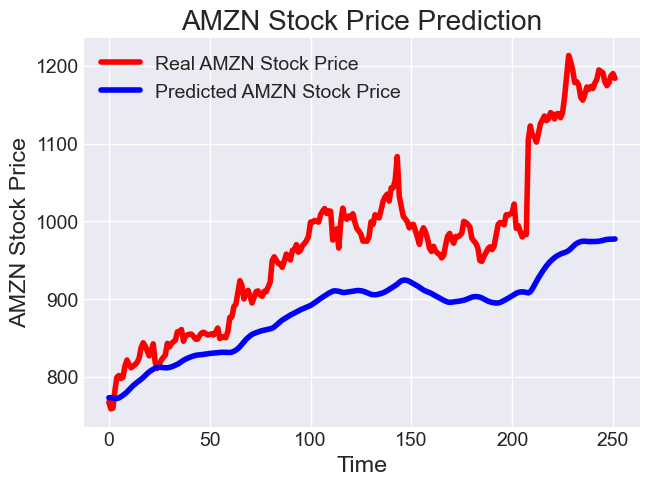

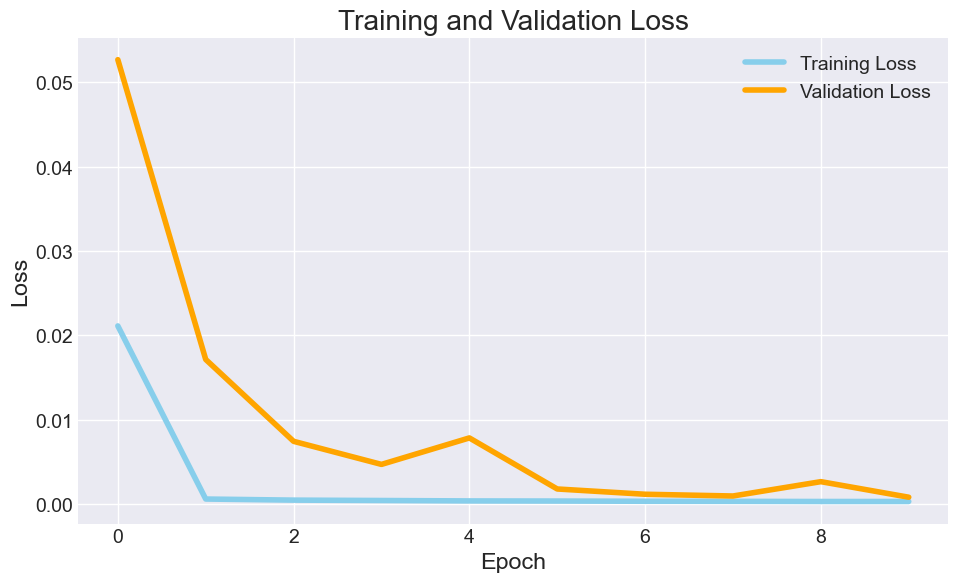

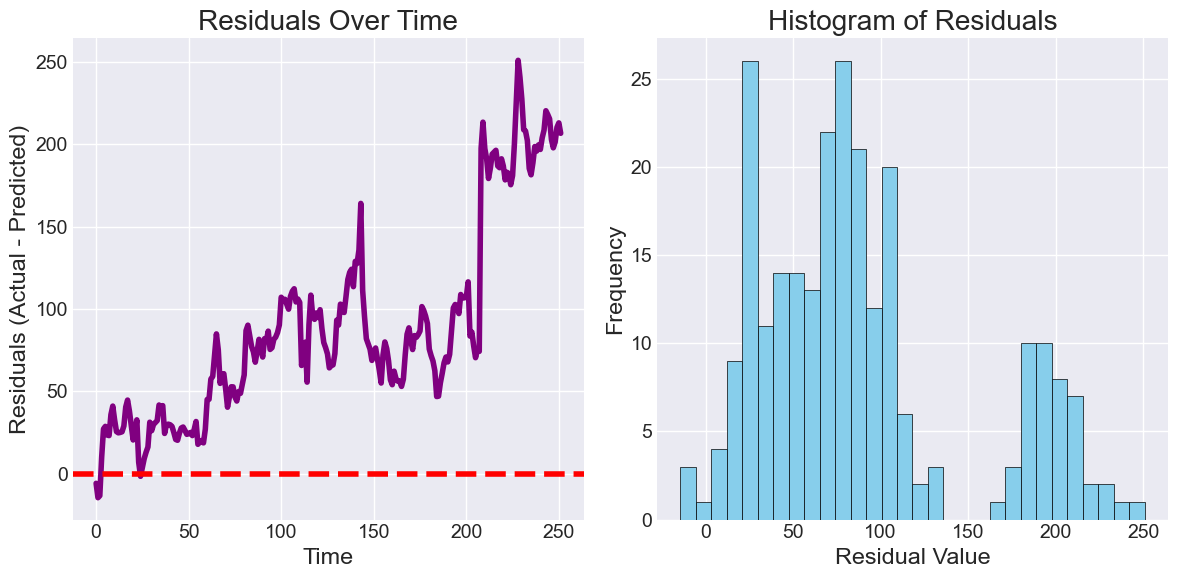

The root mean squared error is 106.62734291113453.


In [23]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(120,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-120:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(120, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 120:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 120:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(120,len(inputs)):
    X_test.append(inputs[i-120:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 6.3: Very Short Sequence Length
This sub-experiment sets the sequence length to 5. This will test the model's ability to predict based on very recent data.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0888 - val_loss: 0.3438
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0185 - val_loss: 0.0434
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3831e-04 - val_loss: 0.0096
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.8246e-04 - val_loss: 0.0069
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5888e-04 - val_loss: 0.0074
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6465e-04 - val_loss: 0.0054
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3500e-04 - val_loss: 0.0052
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3898e-04 - val_loss: 0.0054
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1109e-04 - val_loss: 0.0030
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0697e-04 - val_loss: 0.0042
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


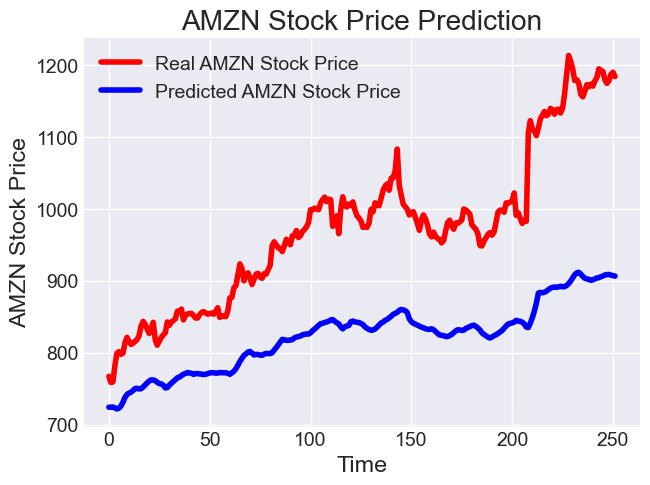

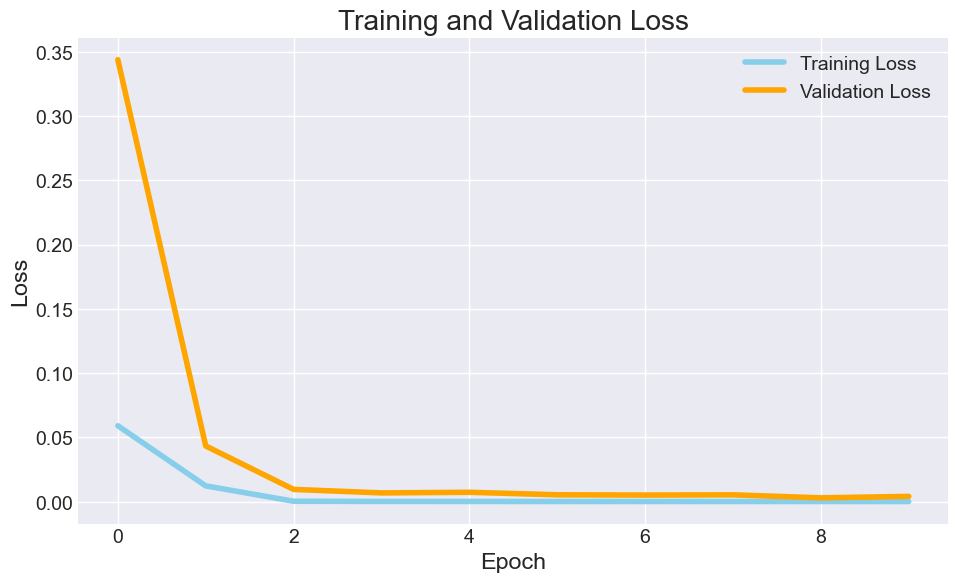

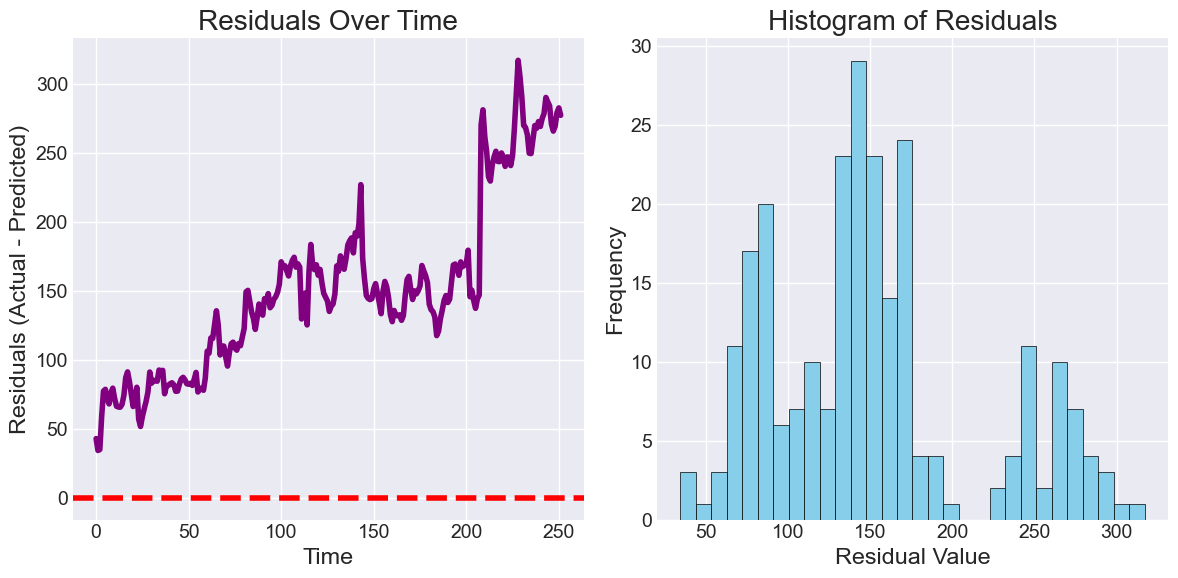

The root mean squared error is 163.5231363313038.


In [24]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(5,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-5:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(5, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 5:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 5:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(5,len(inputs)):
    X_test.append(inputs[i-5:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #7: Different Activation Functions

This experiment explores how different activation functions affect the model's ability to capture various types of relationships in the data. The following sub-experiments are the different number of sequence length conducted:
-  Experiment 7.1: Using `relu` Activation
- Experiment 7.2: Using `sigmoid` Activation
- Experiment 7.3: `relu` in the Output Dense Layer
- Experiment 7.4: `sigmoid` in the Output Dense Layer

### Experiment 7.1: Using `relu` Activation
This sub-experiment uses `relu` activation in the LSTM layers. ReLU (Rectified Linear Unit) is a popular activation function known for its simplicity and efficiency.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0925 - val_loss: 0.3956
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0211 - val_loss: 0.0997
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0063 - val_loss: 0.0230
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0025 - val_loss: 9.1892e-04
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 0.0038
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.9863e-04 - val_loss: 0.0013
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.7139e-04 - val_loss: 0.0058
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.9423e-04 - val_loss: 0.0012
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.0709e-04 - val_loss: 0.0035
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.2260e-04 - val_loss: 0.0019
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


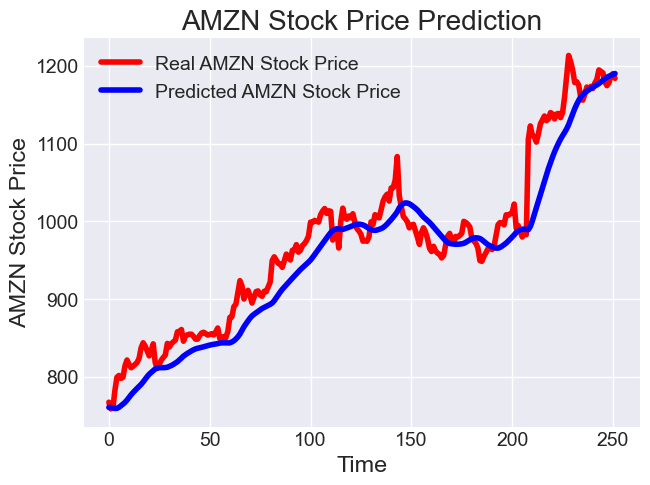

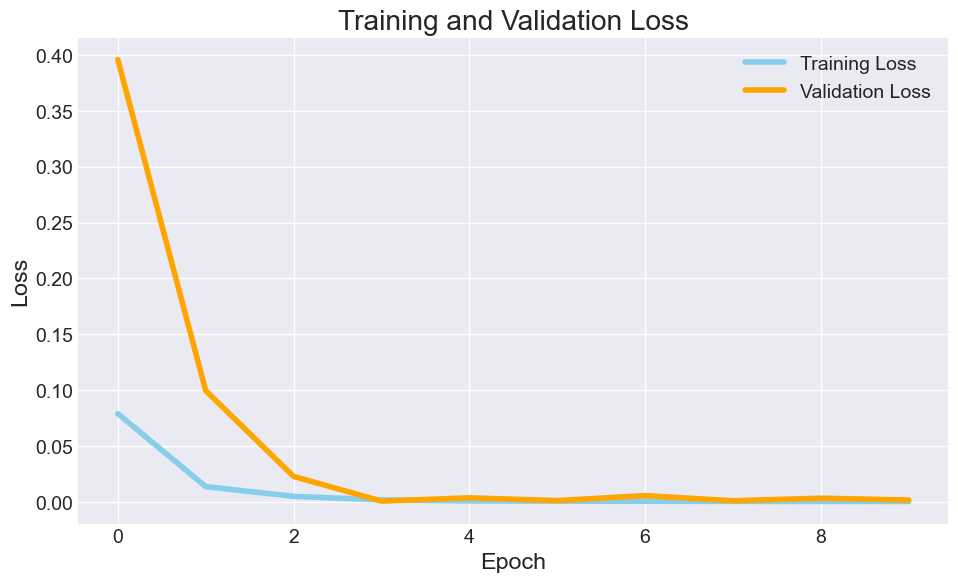

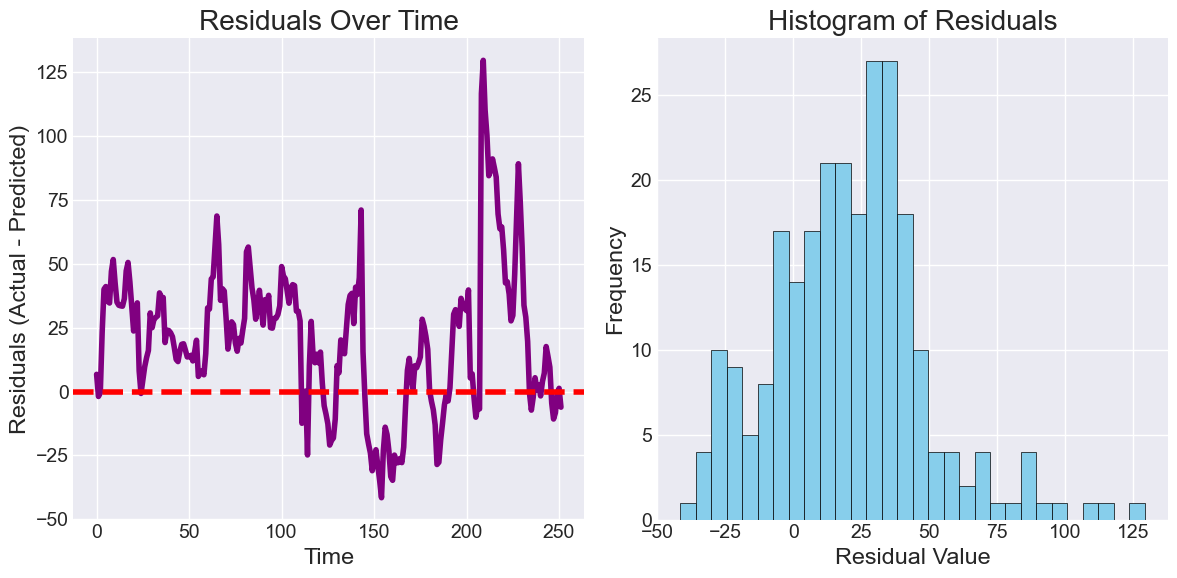

The root mean squared error is 34.759094051469376.


In [25]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, activation='relu', input_shape=(X_train.shape[1],1)))  # Changed activation function to relu on both LSTM layers
regressor.add(LSTM(units=5, activation='relu')) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 7.2: Using `sigmoid` Activation
This sub-experiment uses `sigmoid` activation in the LSTM layers.  Sigmoid outputs values between 0 and 1, which can be useful for probabilities but can also lead to the vanishing gradient problem, especially in deep networks.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0452 - val_loss: 0.6795
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0444 - val_loss: 0.6595
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0438 - val_loss: 0.6600
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0455 - val_loss: 0.6487
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0428 - val_loss: 0.6170
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0403 - val_loss: 0.6016
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0391 - val_loss: 0.5799
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0368 - val_loss: 0.5064
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0333 - val_loss: 0.3936
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0216 - val_loss: 0.2607
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


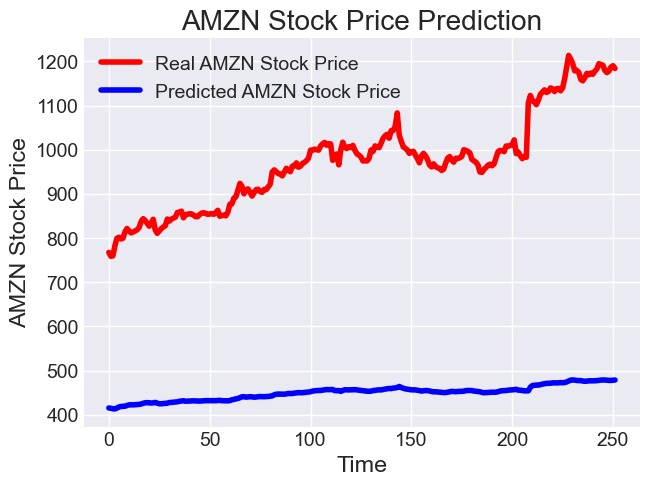

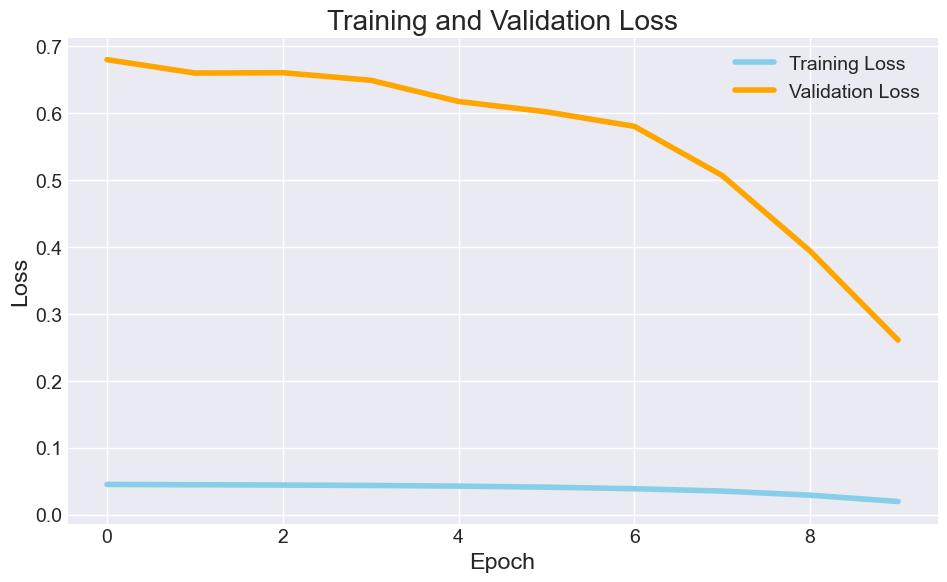

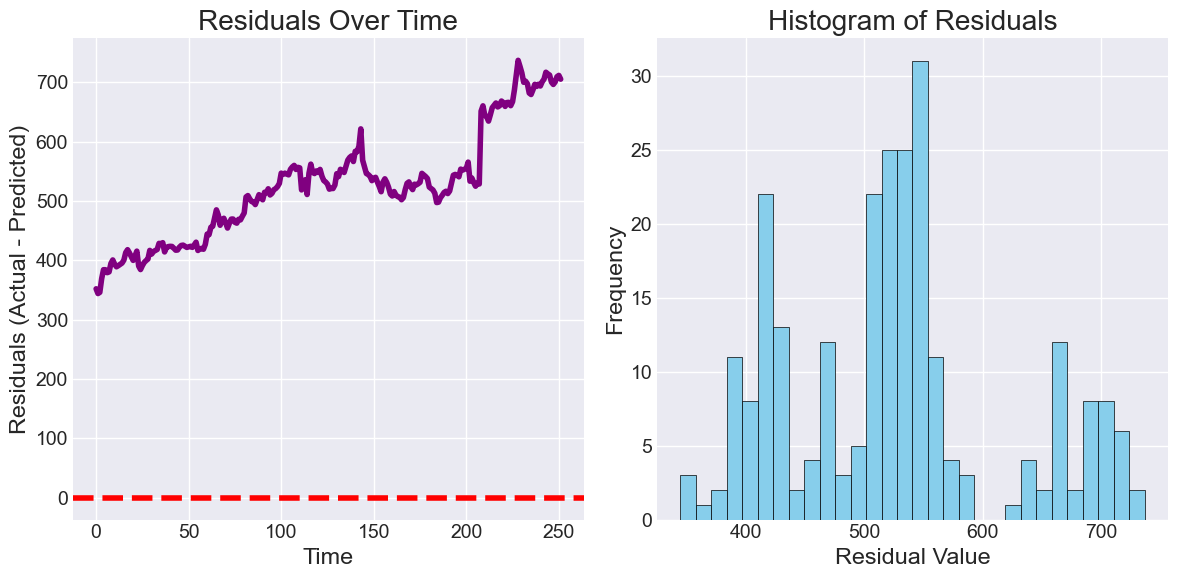

The root mean squared error is 532.2565461424956.


In [26]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, activation='sigmoid', input_shape=(X_train.shape[1],1)))  # Changed activation function to sigmoid on both LSTM layers
regressor.add(LSTM(units=5, activation='sigmoid')) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 7.3: `relu` on Dense Output Layer
This sub-experiment uses `relu` activation in the Dense Output Layer. This would constrain predictions to be non-negative. While stock prices are generally positive, this might limit the model's flexibility.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0361 - val_loss: 0.1313
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024 - val_loss: 0.0791
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0014 - val_loss: 0.0501
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.7066e-04 - val_loss: 0.0323
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.1416e-04 - val_loss: 0.0245
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.0262e-04 - val_loss: 0.0148
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.4828e-04 - val_loss: 0.0139
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6933e-04 - val_loss: 0.0082
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6905e-04 - val_loss: 0.0109
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.1720e-04 - val_loss: 0.0061
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


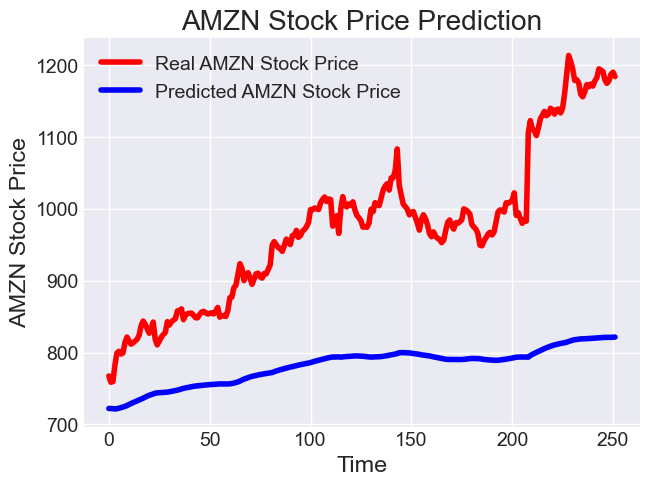

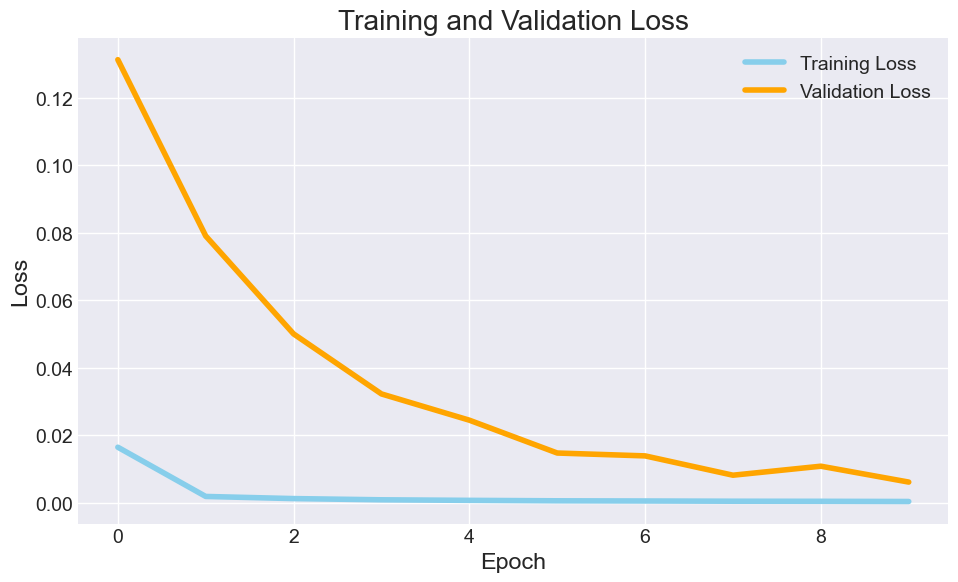

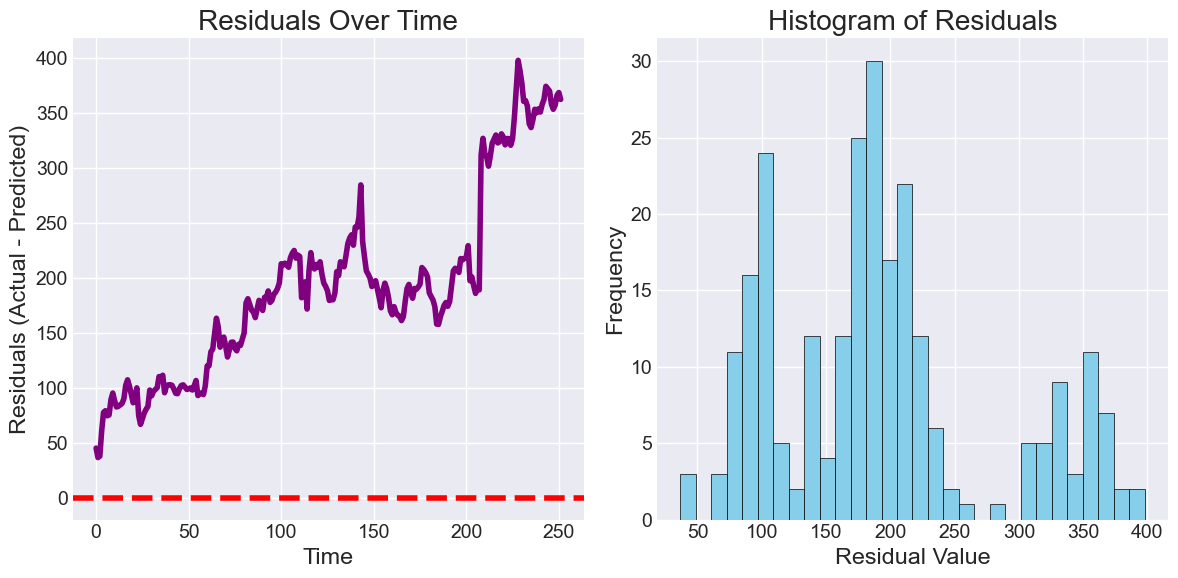

The root mean squared error is 210.04999249068683.


In [27]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1, activation='relu')) # Changed activation function to relu on dense output layer

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 7.4: `sigmoid` on Dense Output Layer
This sub-experiment uses `sigmoid` activation in the Dense Output Layer. This would constrain predictions to be between 0 and 1, which is not suitable for direct stock price prediction.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1109 - val_loss: 1.1623
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1157 - val_loss: 1.1623
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1055 - val_loss: 1.1623
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1156 - val_loss: 1.1623
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1145 - val_loss: 1.1623
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1113 - val_loss: 1.1623
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1102 - val_loss: 1.1623
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1091 - val_loss: 1.1623
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1059 - val_loss: 1.1623
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1079 - val_loss: 1.1623
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


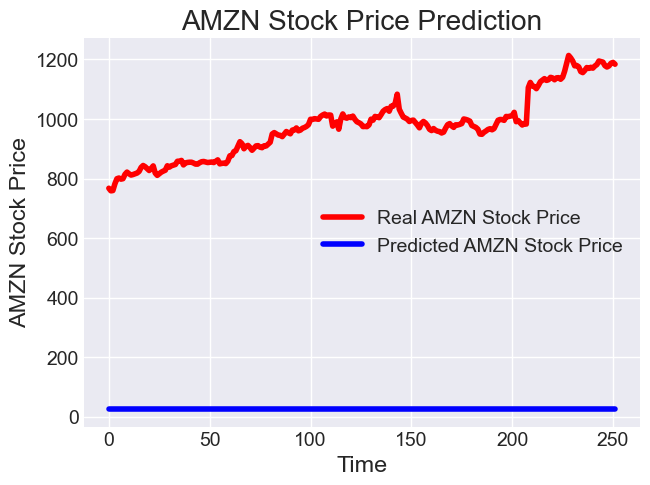

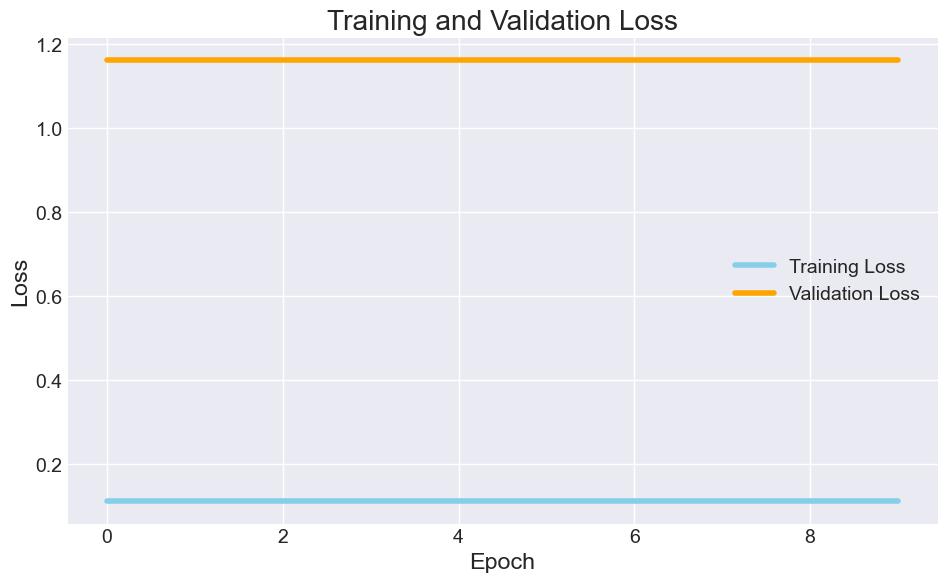

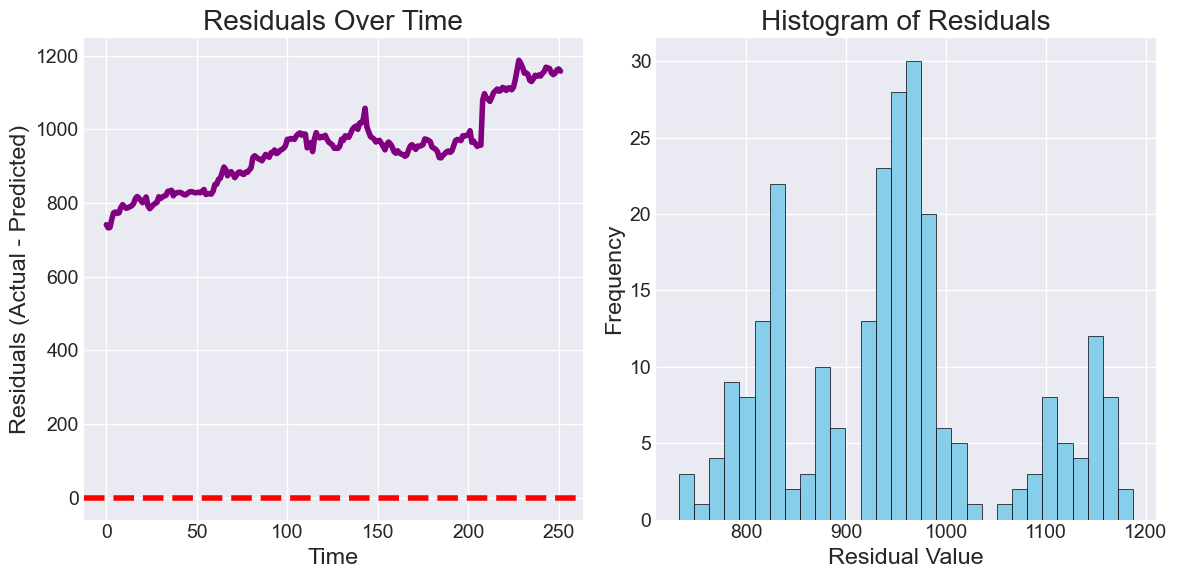

The root mean squared error is 953.5852113363245.


In [28]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))  
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1, activation='relu')) # Changed activation function to relu on dense output layer

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #8: Adding Dropout to Input or LSTM Layers

This experiment explores how dropout affects the model's ability to learn more robust features that are not reliant on specific neurons. The following sub-experiments are the different implementation of dropout conducted:
- Experiment 8.1: Adding Dropout After the First LSTM Layer
- Experiment 8.2: Adding Dropout After the Second LSTM Layer
- Experiment 8.3: Adding Dropout to Both LSTM Layers
- Experiment 8.4: Adding Dropout to the Input Sequence 
- Experiment 8.5: Combining Dropout in LSTM Layers and Input

### Experiment 8.1: Adding Dropout After the First LSTM Layer
This sub-experiment applies dropout rate of 0.2 after the first LSTM layer. This could help prevent overfitting.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0103 - val_loss: 0.0641
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 0.0246
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3105e-04 - val_loss: 0.0089
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.1464e-04 - val_loss: 0.0086
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.1975e-04 - val_loss: 0.0141
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.7619e-04 - val_loss: 0.0116
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.6612e-04 - val_loss: 0.0086
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.6828e-04 - val_loss: 0.0069
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.9977e-04 - val_loss: 0.0080
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8263e-04 - val_loss: 0.0074
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


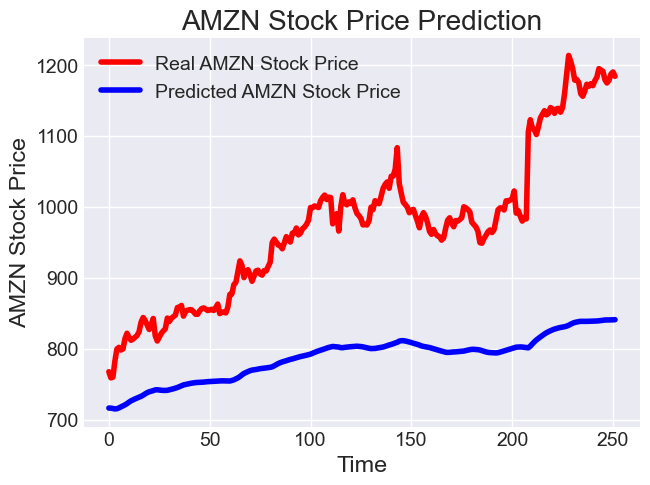

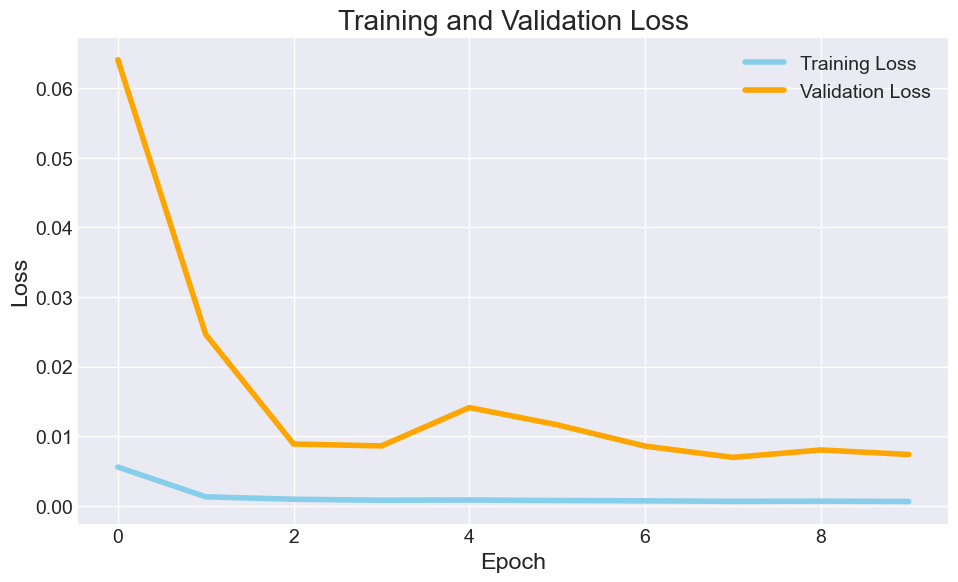

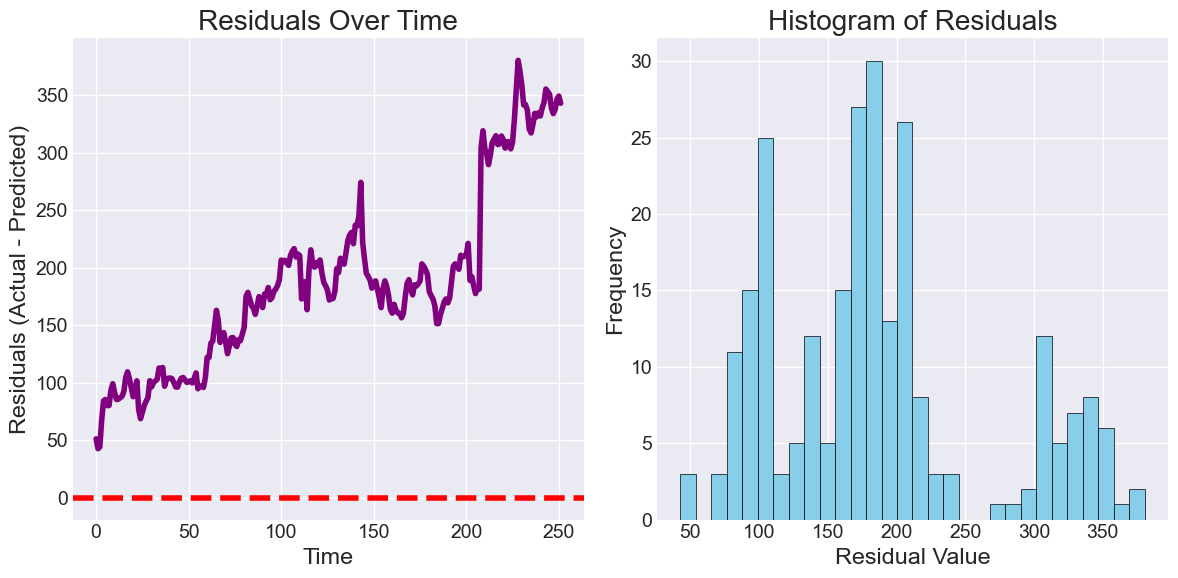

The root mean squared error is 202.18600023431432.


In [29]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2)) # Dropout after the first LSTM
regressor.add(LSTM(units=5)) 
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 8.2: Adding Dropout After the Second LSTM Layer
This sub-experiment applies dropout rate of of 0.2 after the second LSTM layer. This could further regularize the features.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0525 - val_loss: 0.0523
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0056 - val_loss: 0.0050
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0043 - val_loss: 0.0061
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0038 - val_loss: 0.0016
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027 - val_loss: 0.0075
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0023 - val_loss: 0.0011
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


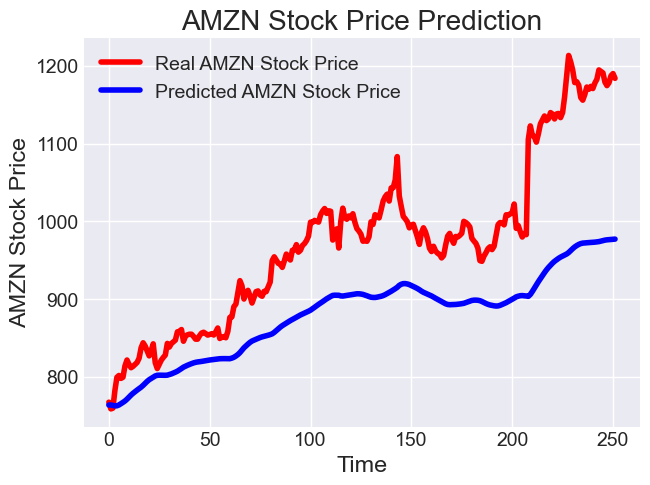

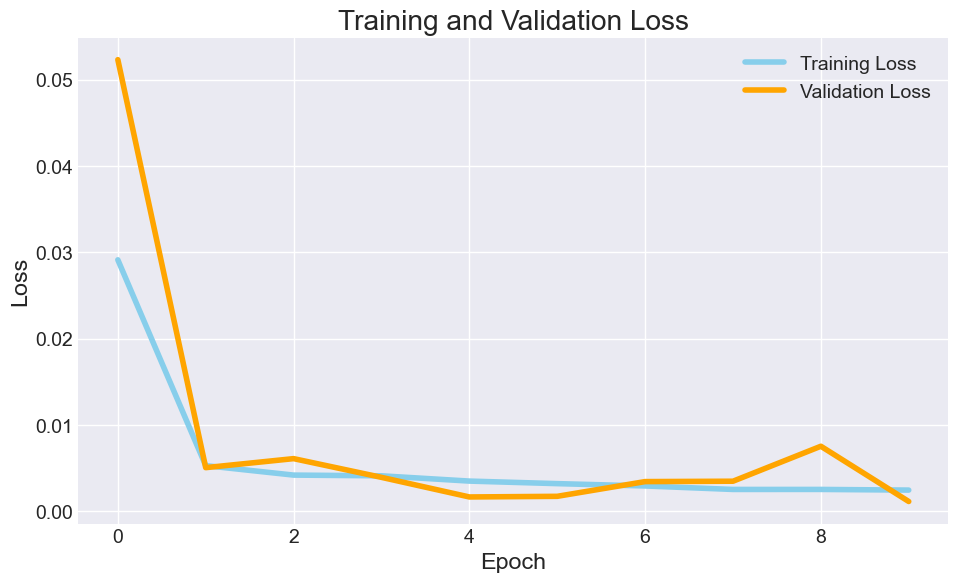

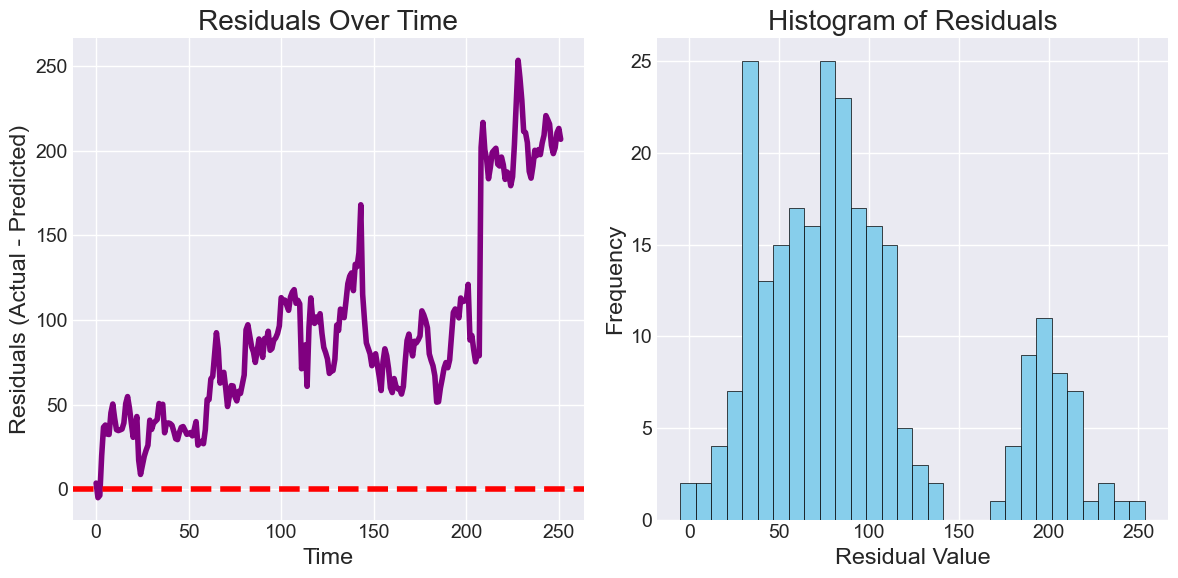

The root mean squared error is 110.30351767676751.


In [30]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5))
regressor.add(Dropout(0.2)) # Dropout after the second LSTM
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 8.3: Adding Dropout to Both LSTM Layer
This sub-experiment applies dropout rate of of 0.2 to both LSTM layer. This will apply a stronger regularization effect to the recurrent part of the network.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0847 - val_loss: 0.1929
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0130 - val_loss: 0.0207
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0075 - val_loss: 0.0225
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0062 - val_loss: 0.0094
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0056 - val_loss: 0.0250
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0041 - val_loss: 0.0195
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0042 - val_loss: 0.0172
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0038 - val_loss: 0.0271
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0039 - val_loss: 0.0158
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0031 - val_loss: 0.0073
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


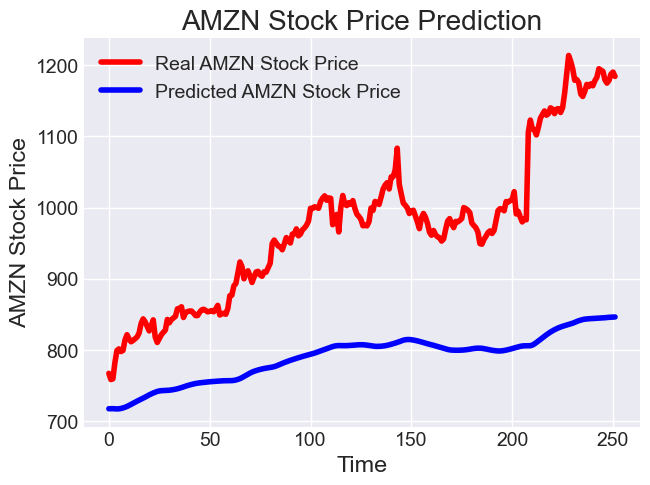

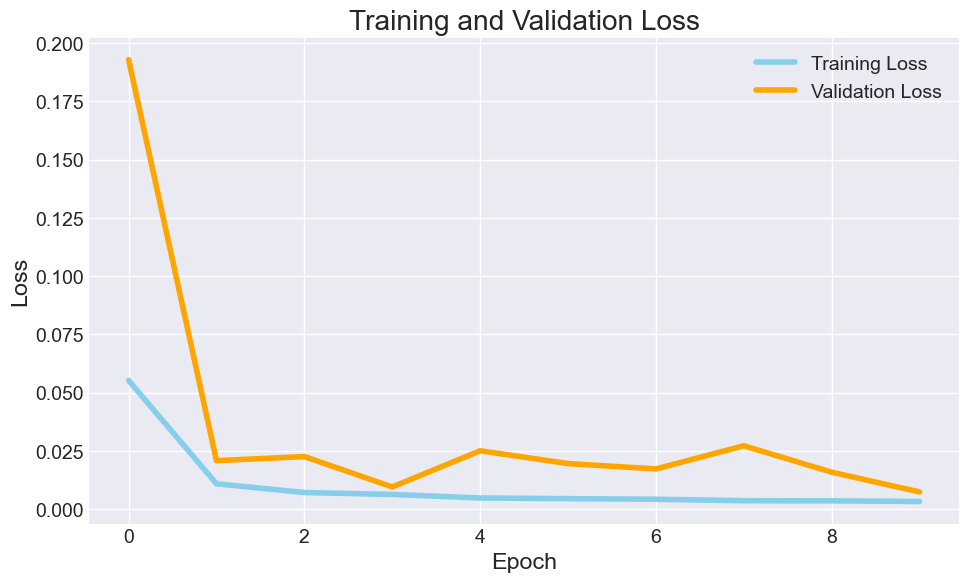

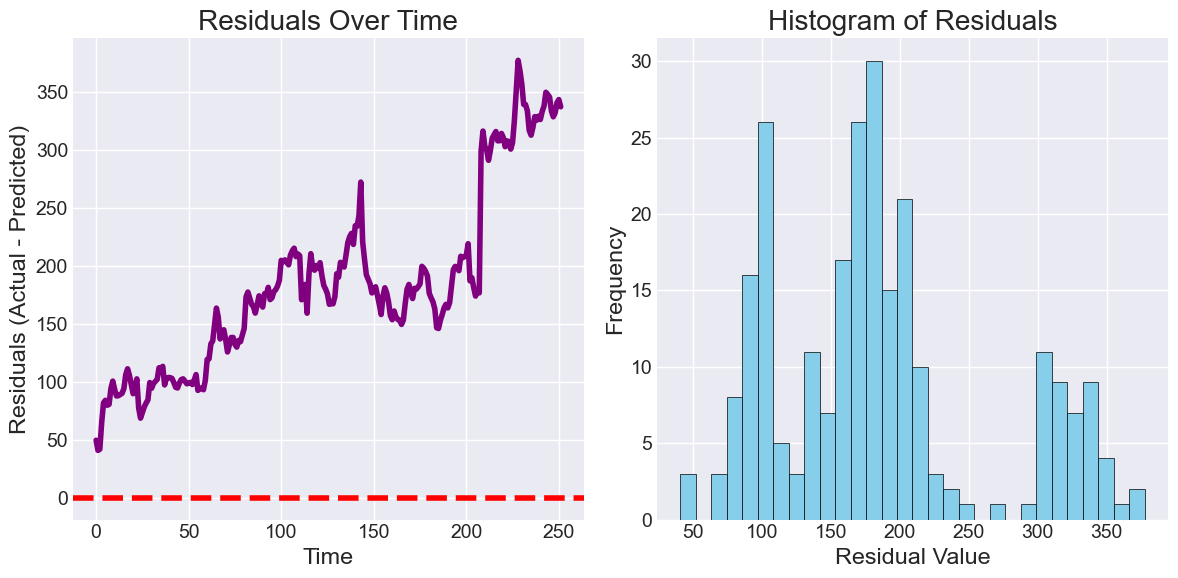

The root mean squared error is 199.52464076997683.


In [31]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(Dropout(0.2)) # Dropout after the first LSTM
regressor.add(LSTM(units=5))
regressor.add(Dropout(0.2)) # Dropout after the second LSTM
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 8.4: Adding Dropout to the Input Sequence
This sub-experiment applies dropout rate of of 0.2 to the input sequence. This could help make the model more robust to noise in the input data.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0904 - val_loss: 0.6053
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0200 - val_loss: 0.2546
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0043 - val_loss: 0.1087
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0027 - val_loss: 0.0570
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 0.0286
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0018 - val_loss: 0.0200
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0131
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 0.0078
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016 - val_loss: 0.0076
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0126
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


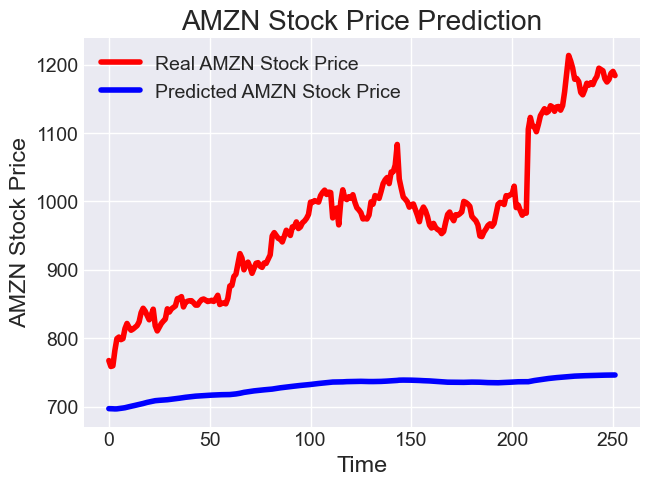

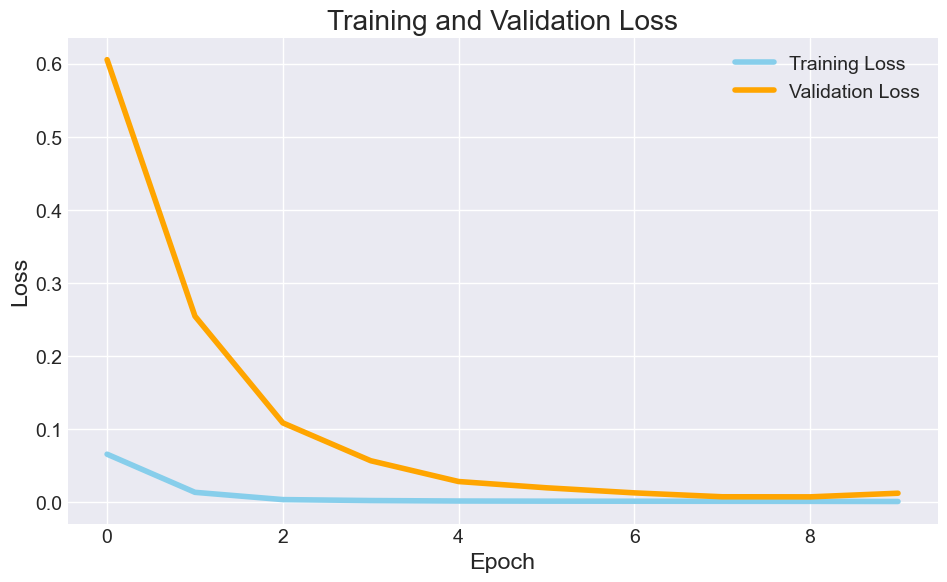

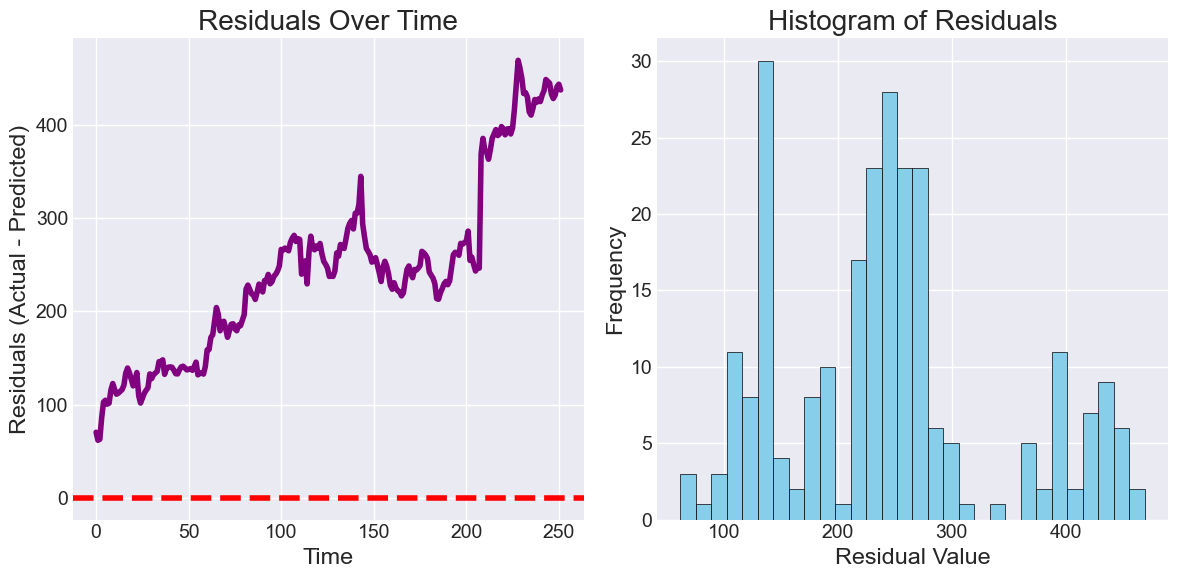

The root mean squared error is 262.84325470452177.


In [32]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(Dropout(0.2, input_shape=(X_train.shape[1], 1))) # Dropout on the input
regressor.add(LSTM(units=5, return_sequences=True))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 8.5: Combining Dropout in Recurrent Layers and Input
This sub-experiment combines dropout rate of of 0.2 to both LSTM layers and input sequence. This explores the combined effect of regularizing both the input and the internal representations of the RNN.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0569 - val_loss: 0.2990
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0111 - val_loss: 0.1062
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0077 - val_loss: 0.0728
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0070 - val_loss: 0.0362
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0052 - val_loss: 0.0259
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0057 - val_loss: 0.0289
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0047 - val_loss: 0.0261
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0047 - val_loss: 0.0212
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0043 - val_loss: 0.0303
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0041 - val_loss: 0.0163
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


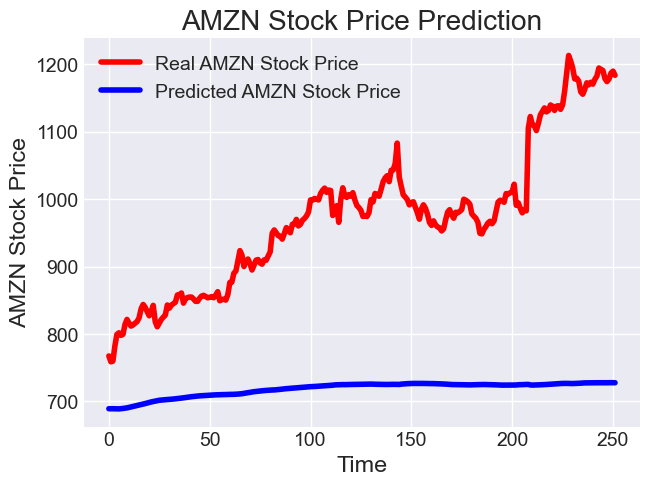

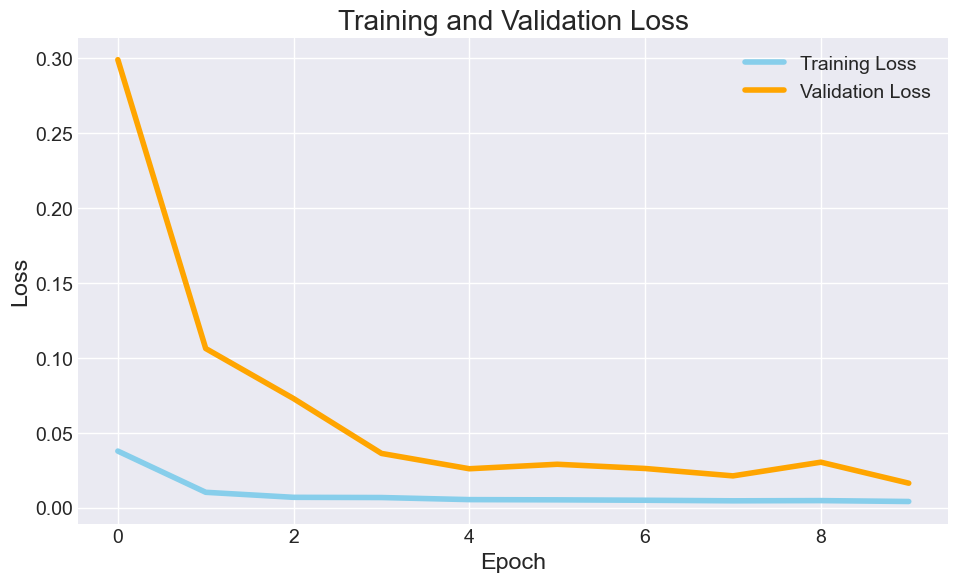

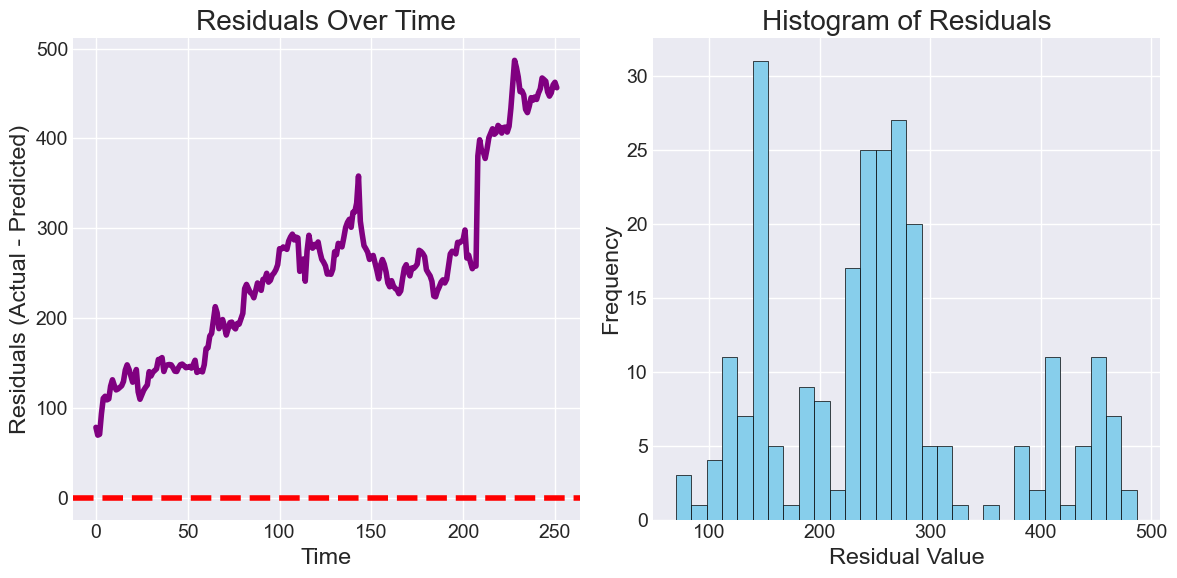

The root mean squared error is 274.3388623281064.


In [33]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(Dropout(0.2, input_shape=(X_train.shape[1], 1))) # Dropout on the input
regressor.add(LSTM(units=5, return_sequences=True))
regressor.add(Dropout(0.2)) # Dropout on the first LSTM layer
regressor.add(LSTM(units=5))
regressor.add(Dropout(0.2)) # Dropout on the second LSTM layer
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #9: Different Optimizers

This experiment explores different optimizers to see their effects on the loss function. The following sub-experiments are the implementation of different optimizers conducted:
- Experiment 9.1: Using Adam Optimizer
- Experiment 9.2: Using SGD Optimizer
- Experiment 9.3: Using Adagrad Optimizer

### Experiment 9.1: Using Adam Optimizer
This sub-experiment uses `adam` as the optimizer for this experiment.  Adam (Adaptive Moment Estimation) is a popular and generally effective optimizer that combines the benefits of AdaGrad and RMSprop.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0359 - val_loss: 0.0170
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9803e-04 - val_loss: 0.0089
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.8899e-04 - val_loss: 0.0068
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6589e-04 - val_loss: 0.0063
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9137e-04 - val_loss: 0.0056
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2907e-04 - val_loss: 0.0037
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.1689e-04 - val_loss: 0.0016
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.4318e-04 - val_loss: 0.0035
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0882e-04 - val_loss: 0.0024
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.7248e-04 - val_loss: 0.0034
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


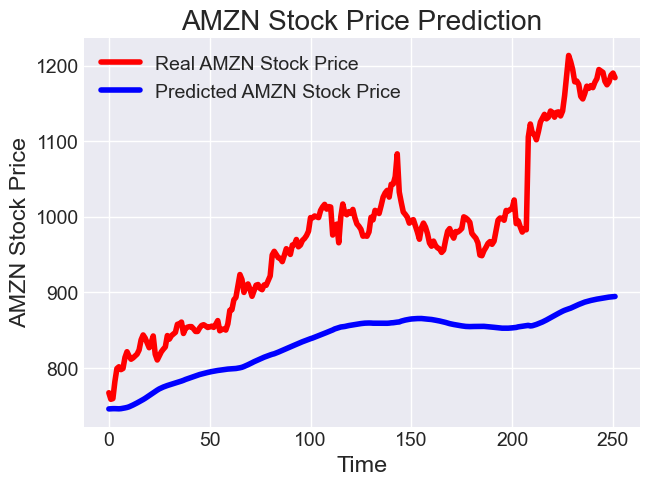

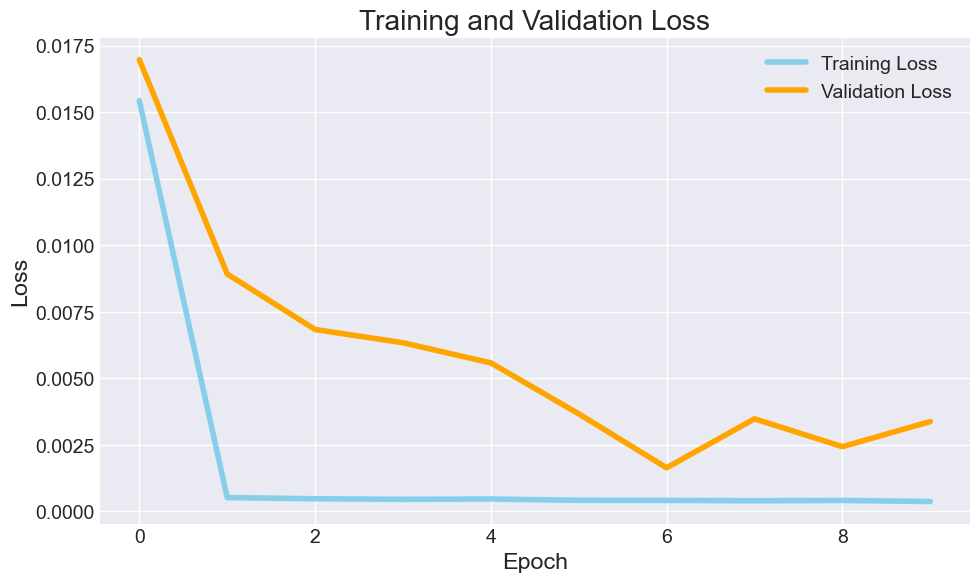

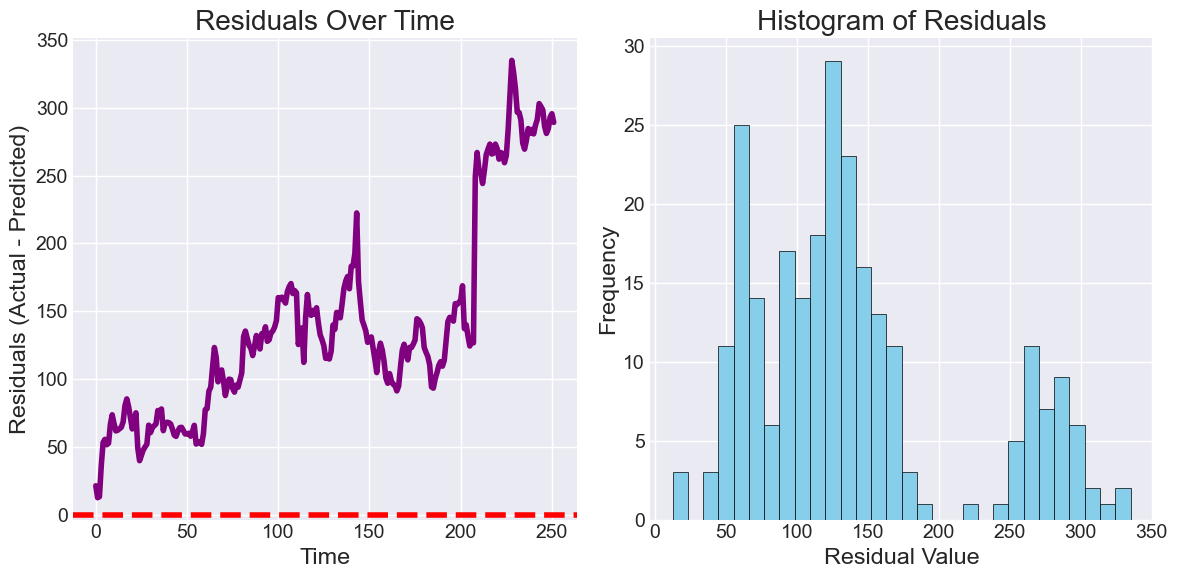

The root mean squared error is 157.99210547781746.


In [34]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='adam',loss='mean_squared_error')    # Changed optimizer to adam
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 9.2: Using SGD Optimizer
This sub-experiment uses `sgd` as the optimizer for this experiment.  SGD (Stochastic Gradient Descent) is the classic optimization algorithm. It updates weights based on the gradient of the loss on a single batch of data.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0895 - val_loss: 0.5321
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0313 - val_loss: 0.3513
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0178 - val_loss: 0.2403
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0092 - val_loss: 0.1718
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0041 - val_loss: 0.1310
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022 - val_loss: 0.1108
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0017 - val_loss: 0.0988
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 0.0897
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 0.0834
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0781
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


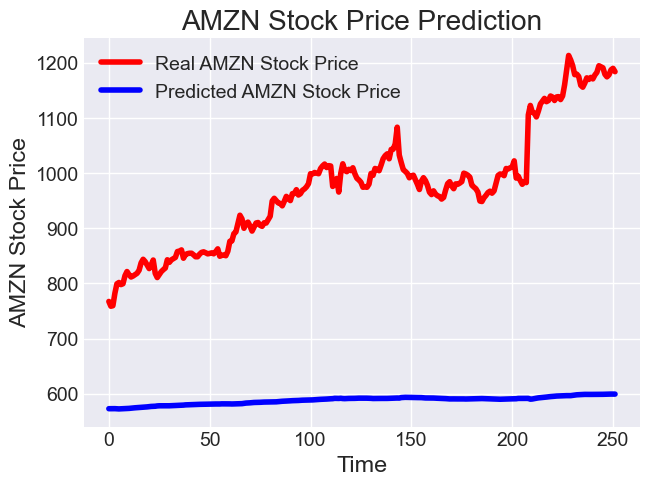

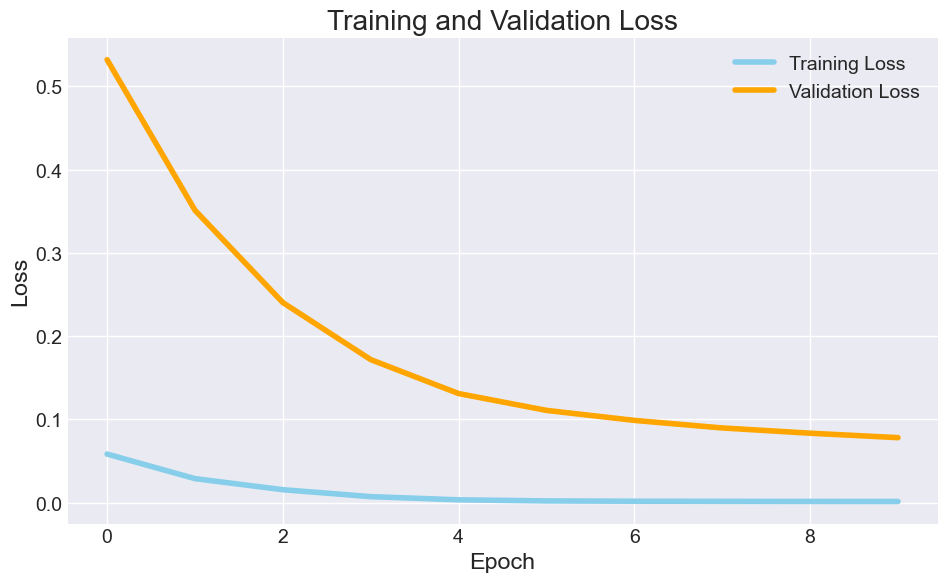

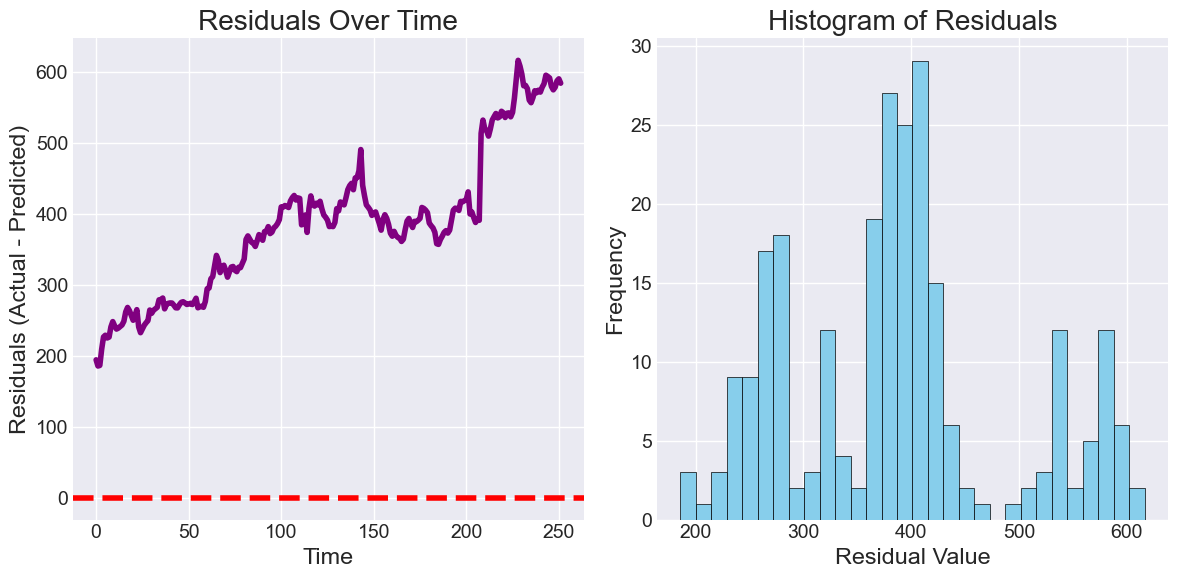

The root mean squared error is 398.8760488007052.


In [35]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='sgd',loss='mean_squared_error')    # Changed optimizer to sgd
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

### Experiment 9.3: Using Adagrad Optimizer
This sub-experiment uses `adagrad` as the optimizer for this experiment.  Adagrad adapts the learning rate for each parameter based on the historical gradients that have been computed for that parameter.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0875 - val_loss: 0.8424
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0693 - val_loss: 0.7718
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0567 - val_loss: 0.7184
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0507 - val_loss: 0.6752
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0455 - val_loss: 0.6391
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0401 - val_loss: 0.6084
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0364 - val_loss: 0.5820
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0347 - val_loss: 0.5592
Epoch 9/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0309 - val_loss: 0.5393
Epoch 10/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0301 - val_loss: 0.5219
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


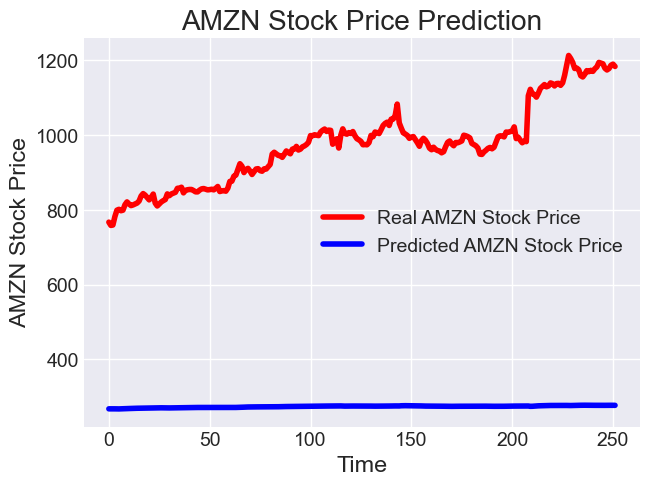

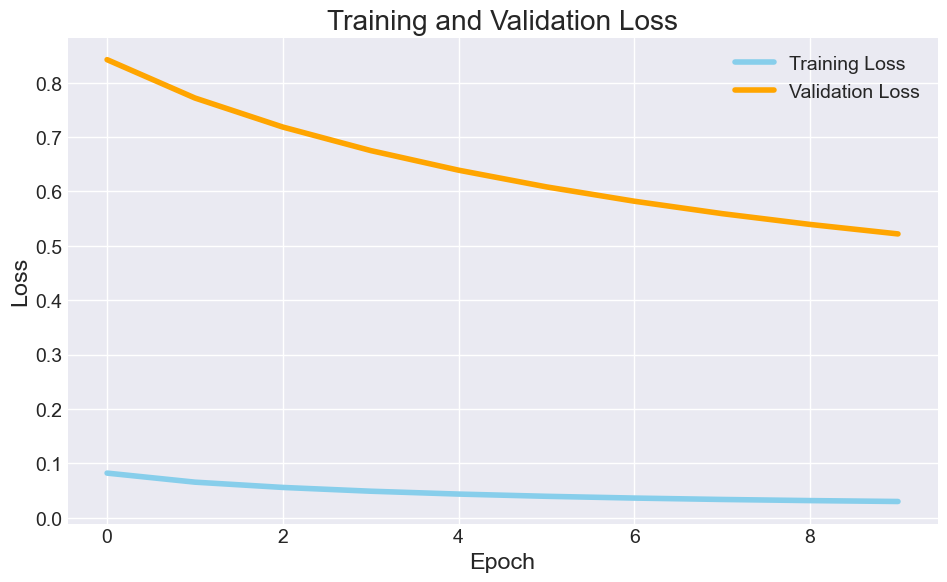

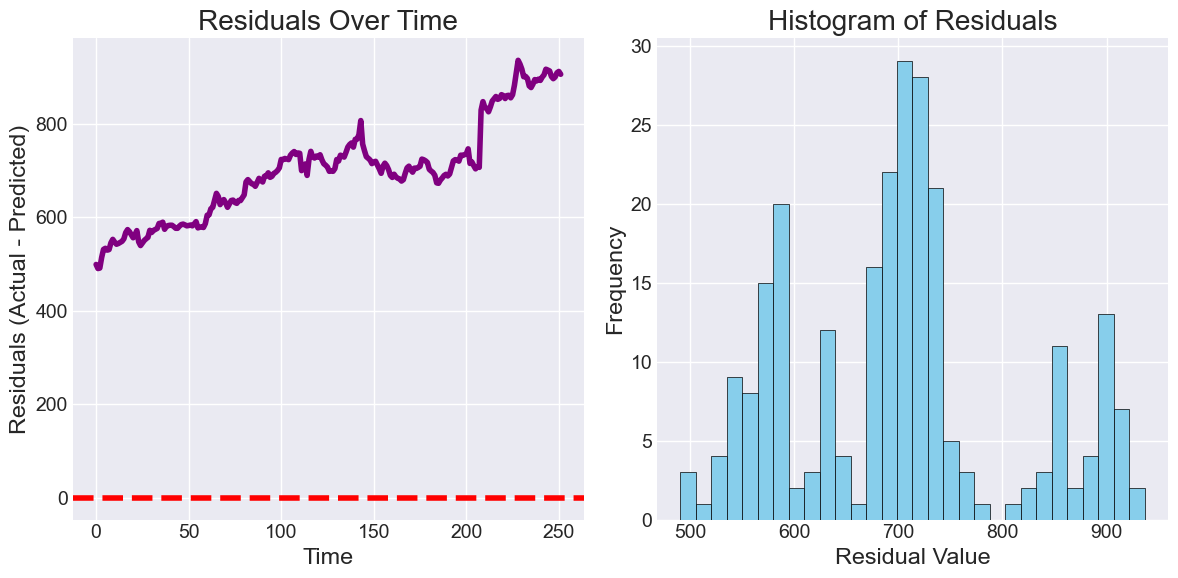

The root mean squared error is 707.6122950449328.


In [36]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])

# Splitting the data into training and a temporary set
training_set = dataset[:'2015'].iloc[:, 1:2].values
temp_data = dataset['2016':].iloc[:, 1:2].values 

# Further split the temporary data into validation and test sets
validation_size = int(0.5 * len(temp_data)) 
validation_set = temp_data[:validation_size]
test_set = temp_data[validation_size:]

# Preprocessing the data (using min-max scaler as baseline)
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)
validation_set_scaled = sc.transform(validation_set)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, 0])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='adagrad',loss='mean_squared_error')    # Changed optimizer to adagrad
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
inputs = dataset[len(training_set) + len(validation_set) - 60:].iloc[:, 1:2].values
inputs = sc.transform(inputs)

X_test = []
for i in range(60,len(inputs)):
    X_test.append(inputs[i-60:i,0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_set,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_set, predicted_stock_price)

return_rmse(test_set,predicted_stock_price)

## Experiment #10: Lagged Features (Feature Engineering)

This experiment explores whether creating new input features based on past values of the stock price can improve the model's predictive performance. The following sub-experiments are the lagged features conducted:
- Experiment 10.1: Adding the Previous Day's Price
- Experiment 10.2: Adding a Moving Average
- Experiment 10.3: Adding the Price Change
- Experiment 10.4: Combining Multiple Lagged Features

### Experiment 10.1: Adding the Previous Day's Price
This sub-experiment include both the current day's 'High' price and the 'High' price from the previous day (lagged by 1 time step). The previous day's price is often a strong indicator of the current day's price due to momentum and short-term trends.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1746 - val_loss: 0.5079
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0157 - val_loss: 0.1255
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0780
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 0.0821
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.3629e-04 - val_loss: 0.0715
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5038e-04 - val_loss: 0.0655
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.5011e-04 - val_loss: 0.0701
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.0918e-04 - val_loss: 0.0704
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.8968e-04 - val_loss: 0.0536
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.2988e-04 - val_loss: 0.0462
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


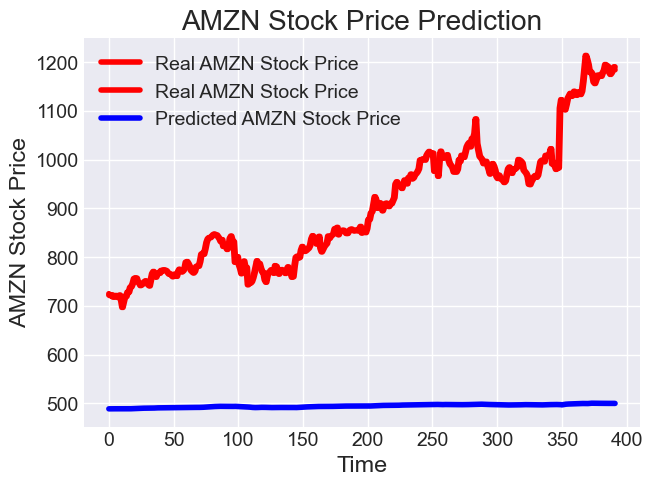

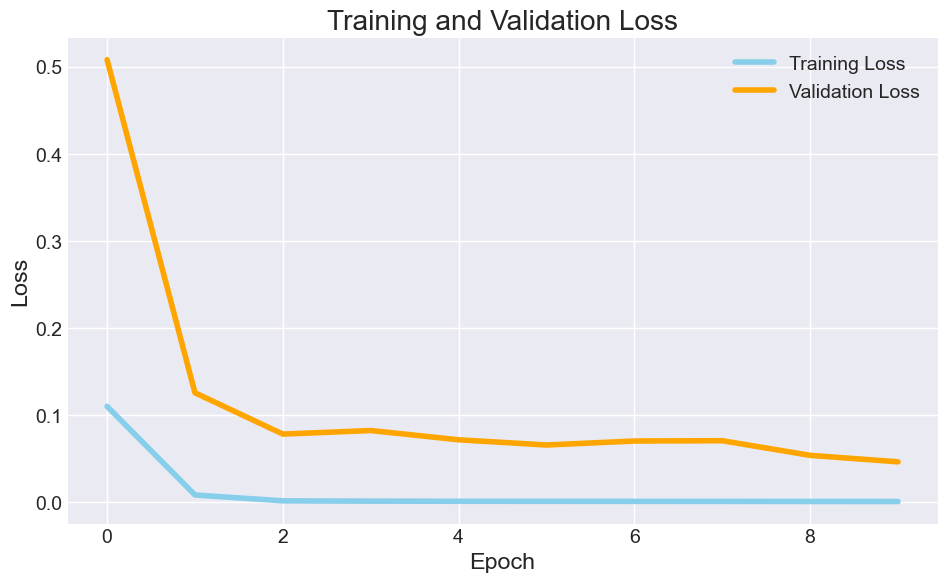

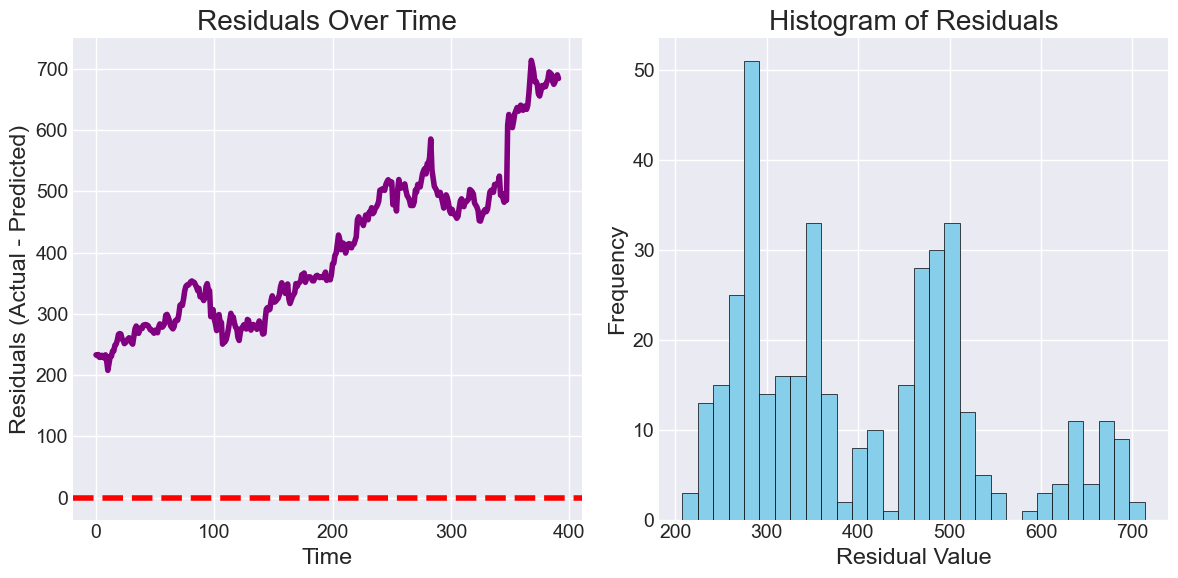

The root mean squared error is 427.06553611890524.


In [37]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])
data = dataset[['High']].values # Create data variable to store high vales

# Split the data into training, validation, and test sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
validation_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

# Create lagged features
def create_lagged_features(data, lags=1):
    df = pd.DataFrame(data)
    for i in range(1, lags +1):
        df[f'lag_{i}'] = df.iloc[:,0].shift(i)
    df.dropna(inplace=True)
    return df.values

train_data = create_lagged_features(train_data, lags=1)
validation_data = create_lagged_features(validation_data, lags=1)
test_data = create_lagged_features(test_data, lags=1)

# Scale the features
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(train_data)
validation_set_scaled = sc.transform(validation_data)
test_set_scaled = sc.transform(test_data)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,:])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],2))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, :])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 2))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],2)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')   
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
X_test = []
y_test = []
for i in range(60,len(test_set_scaled)):
    X_test.append(test_set_scaled[i-60:i,:])
    y_test.append(test_set_scaled[i,0])
    
X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],2))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(np.concatenate([predicted_stock_price, np.zeros_like(predicted_stock_price)], axis=1))[:, 0]

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_data[60:],predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_data[60:, 0], predicted_stock_price)

return_rmse(test_data[60:, 0],predicted_stock_price)

### Experiment 10.2: Adding a Moving Average as a Feature
This sub-experiment include the current day's 'High' price and a simple moving average of the 'High' price over a short window. A 5-day moving average captures the average price over the last trading week.

Epoch 1/10


/var/folders/vs/zcjd1wds7_78_tmdl741y03m0000gn/T/ipykernel_10120/952273659.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return ma.fillna(method='bfill').values.reshape(-1, 1) # Forward fill NaNs
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0614 - val_loss: 0.0903
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - val_loss: 0.0845
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - val_loss: 0.0690
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 0.0721
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 0.0572
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5250e-04 - val_loss: 0.0523
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.0139e-04 - val_loss: 0.0347
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.5222e-04 - val_loss: 0.0331
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.3817e-04 - val_loss: 0.0733
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.5854e-04 - val_loss: 0.0425
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


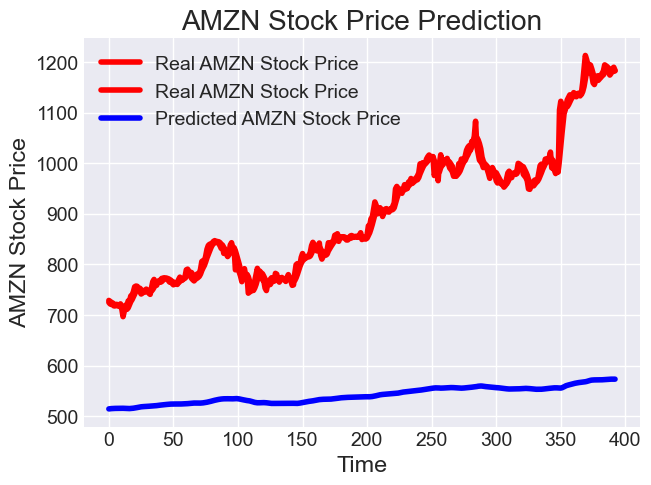

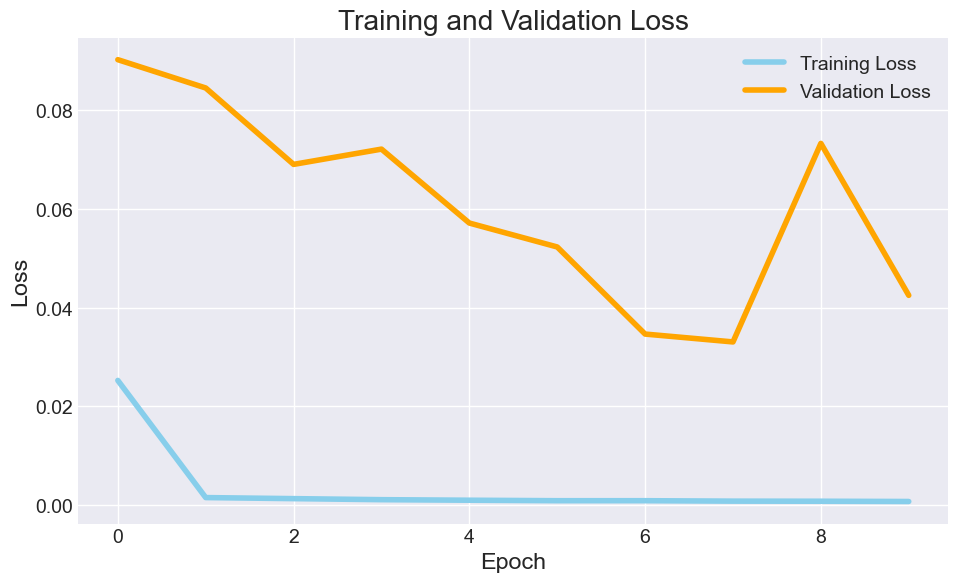

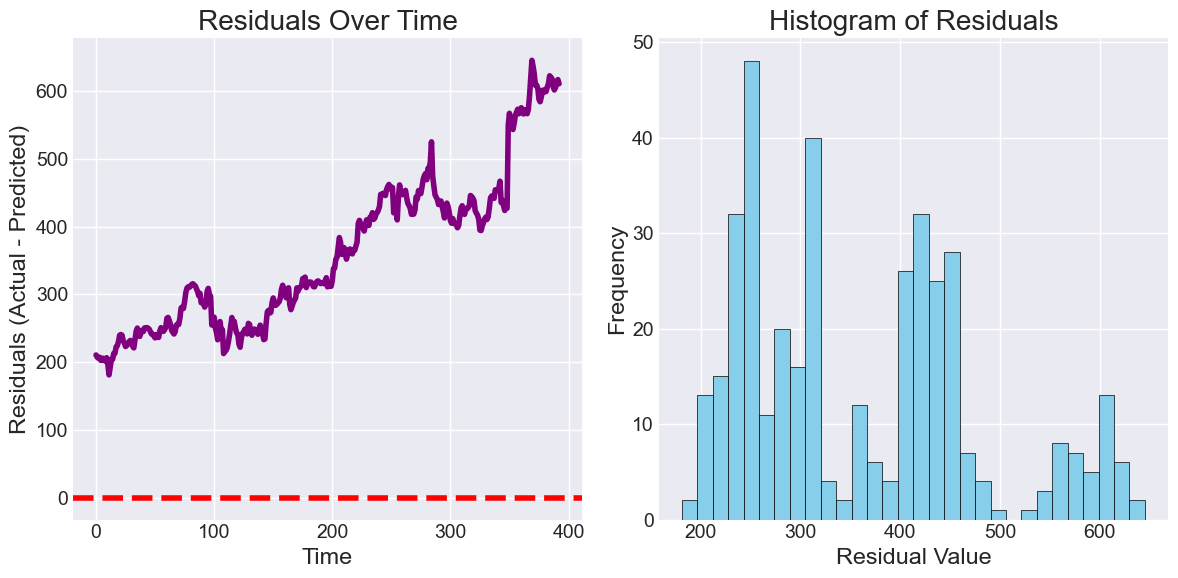

The root mean squared error is 378.5288943512446.


In [38]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])
data = dataset[['High']] # Create data variable to store high vales

# Split the data into training, validation, and test sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
validation_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

# Create the moving average feature
def create_ma_feature(data, window):
    ma = data['High'].rolling(window=window).mean()
    return ma.fillna(method='bfill').values.reshape(-1, 1) # Forward fill NaNs

train_data_ma = create_ma_feature(train_data, window=5)
validation_data_ma = create_ma_feature(validation_data, window=5)
test_data_ma = create_ma_feature(test_data, window=5)

# Combine the original 'High' price with the moving average
train_data = np.concatenate([train_data.values, train_data_ma], axis=1)
validation_data = np.concatenate([validation_data.values, validation_data_ma], axis=1)
test_data = np.concatenate([test_data.values, test_data_ma], axis=1)

# Scale the features
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(train_data)
validation_set_scaled = sc.transform(validation_data)
test_set_scaled = sc.transform(test_data)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,:])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],2))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, :])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 2))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],2)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')   
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
X_test = []
y_test = []
for i in range(60,len(test_set_scaled)):
    X_test.append(test_set_scaled[i-60:i,:])
    y_test.append(test_set_scaled[i,0])
    
X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],2))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(np.concatenate([predicted_stock_price, np.zeros_like(predicted_stock_price)], axis=1))[:, 0]

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_data[60:],predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_data[60:, 0], predicted_stock_price)

return_rmse(test_data[60:, 0],predicted_stock_price)

### Experiment 10.3: Adding the Price Change as a Feature
This sub-experiment include the current day's 'High' price and the difference between the current day's 'High' price and the previous day's 'High' price. The price change can provide information about the direction and magnitude of recent price movements.

Epoch 1/10


/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0945 - val_loss: 0.3418
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0079 - val_loss: 0.1234
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022 - val_loss: 0.1154
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0017 - val_loss: 0.1193
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 0.0914
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - val_loss: 0.0899
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 0.0959
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - val_loss: 0.0734
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 0.0653
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.0497e-04 - val_loss: 0.0611
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


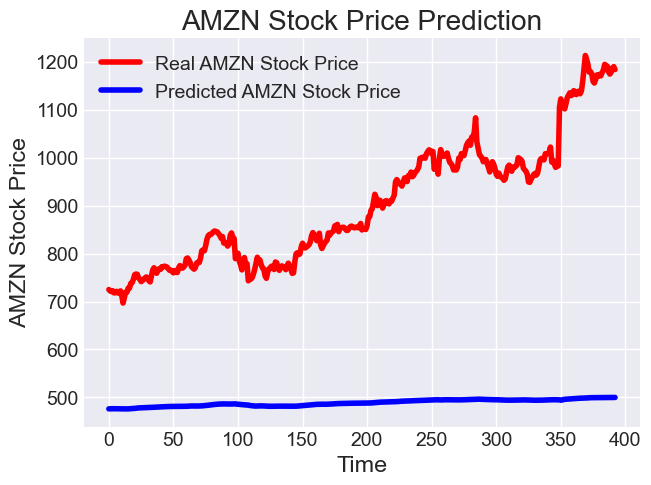

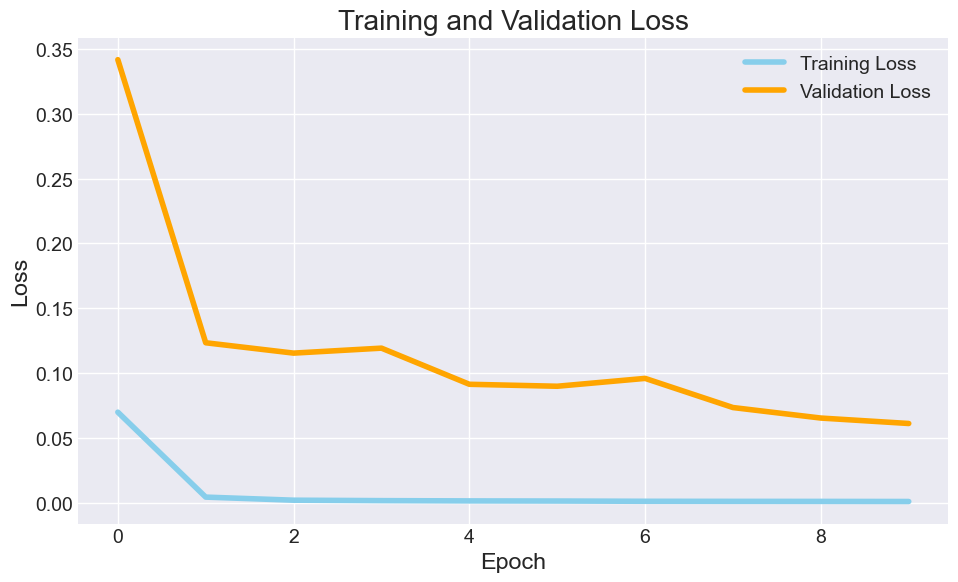

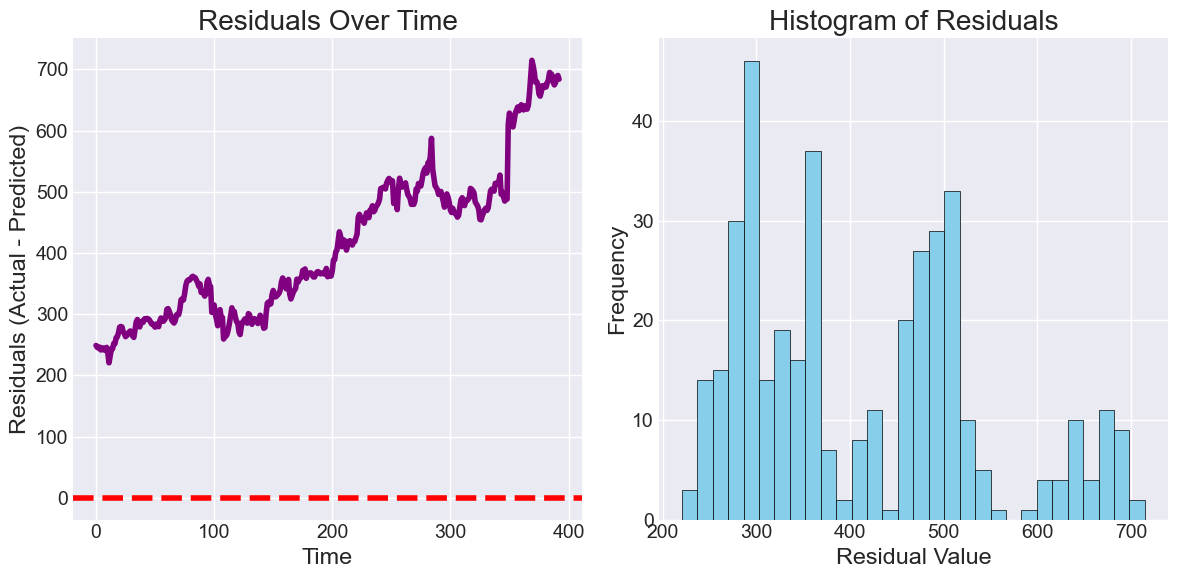

The root mean squared error is 431.6257205519509.


In [39]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date',
parse_dates=['Date'])
data = dataset[['High']] # Create data variable to store high vales

# Split the data into training, validation, and test sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
validation_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

# Create the price change feature
def create_price_change_feature(data):
    price_change = data['High'].diff()
    price_change.fillna(0, inplace=True) # Fill the first NaN with 0
    return price_change.values.reshape(-1, 1)

train_data_pc = create_price_change_feature(train_data)
validation_data_pc = create_price_change_feature(validation_data)
test_data_pc = create_price_change_feature(test_data)

# Combine the original 'High' price with the price change
train_pc = np.concatenate([train_data.values, train_data_pc], axis=1)
validation_pc = np.concatenate([validation_data.values, validation_data_pc], axis=1)
test_pc = np.concatenate([test_data.values, test_data_pc], axis=1)

# Scale the features
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(train_pc)
validation_set_scaled = sc.transform(validation_pc)
test_set_scaled = sc.transform(test_pc)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,:])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],2))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, :])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 2))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],2)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')   
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
X_test = []
y_test = []
for i in range(60,len(test_set_scaled)):
    X_test.append(test_set_scaled[i-60:i,:])
    y_test.append(test_set_scaled[i,0])
    
X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],2))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(np.concatenate([predicted_stock_price, np.zeros_like(predicted_stock_price)], axis=1))[:, 0]

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_data['High'][60:].values,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_data['High'][60:].values, predicted_stock_price)

return_rmse(test_data['High'][60:].values,predicted_stock_price)

### Experiment 10.4: Combining Multiple Lagged Features
This sub-experiment include combining the previous day's price and the 5-day moving average as additional features, along with the current day's 'High' price.. This explores whether providing a richer set of historical information can further improve the model's understanding of the price dynamics.

Epoch 1/10


/var/folders/vs/zcjd1wds7_78_tmdl741y03m0000gn/T/ipykernel_10120/619392626.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return ma.fillna(method='bfill').values.reshape(-1, 1)
/Users/jjelleazarr/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0804 - val_loss: 0.2976
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0024 - val_loss: 0.1210
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.2753e-04 - val_loss: 0.0763
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4513e-04 - val_loss: 0.0594
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.5179e-04 - val_loss: 0.0686
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.3860e-04 - val_loss: 0.0550
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6704e-04 - val_loss: 0.0513
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4295e-04 - val_loss: 0.0481
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.6475e-04 - val_loss: 0.0435
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.3255e-04 - val_loss: 0.0474
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


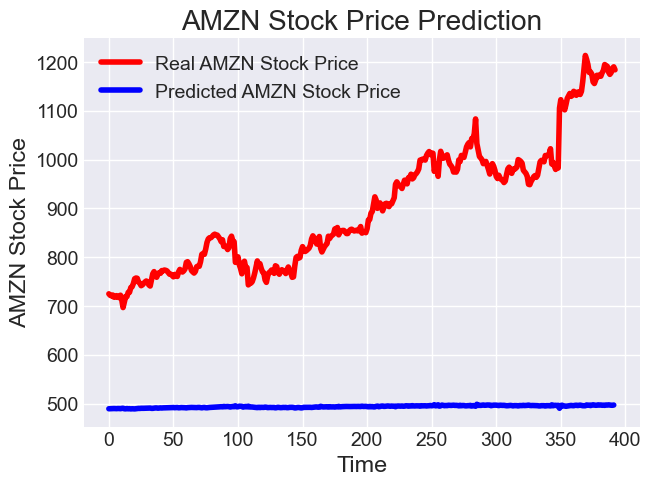

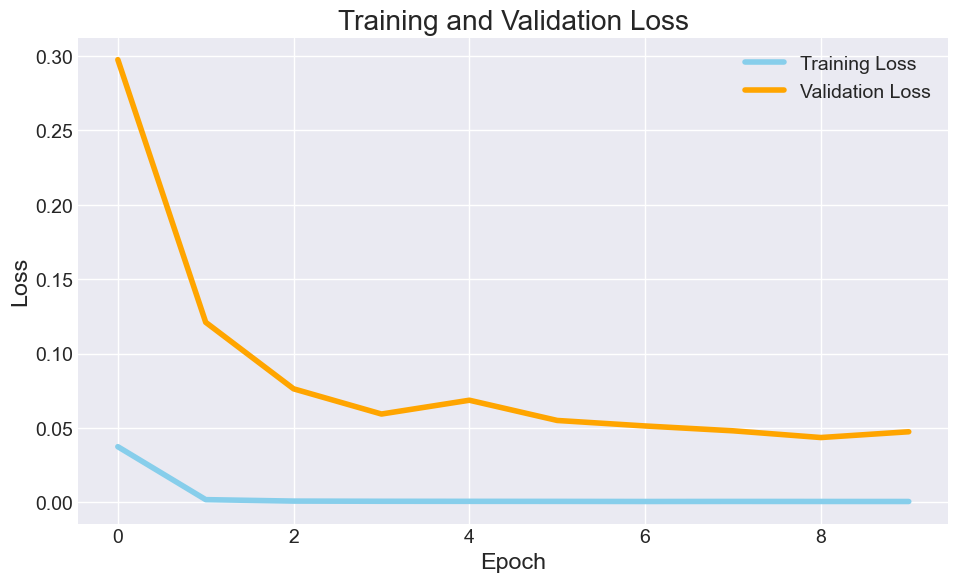

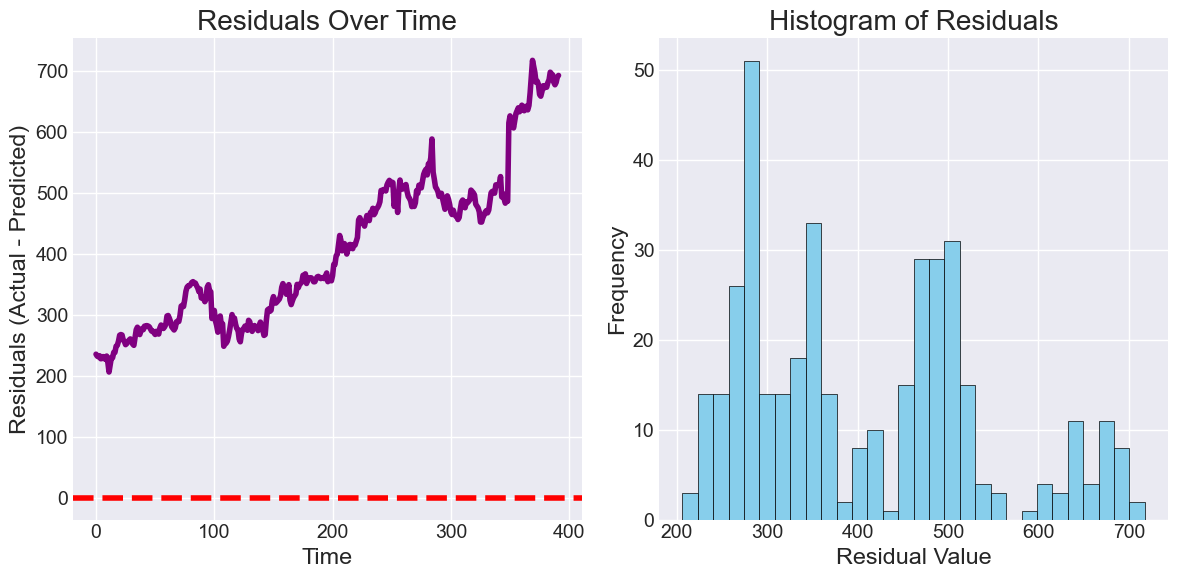

The root mean squared error is 426.9901919474442.


In [ ]:
# Loading the data
dataset = pd.read_csv('AMZN_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
data = dataset[['High']] # Create data variable to store high vales

# Split the data into training, validation, and test sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
validation_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

def create_lagged_feature(data, lags=1):
    data_lag = pd.DataFrame(data['High'])
    for i in range(1, lags + 1):
        data_lag[f'lag_{i}'] = data['High'].shift(i)
    data_lag.dropna(inplace=True)
    return data_lag.values

def create_ma_feature(data, window=5):
    ma = data['High'].rolling(window=window).mean()
    return ma.fillna(method='bfill').values.reshape(-1, 1)

# Create the features
train_lag = create_lagged_feature(train_data, lags=1)
validation_lag = create_lagged_feature(validation_data, lags=1)
test_lag = create_lagged_feature(test_data, lags=1)

train_ma = create_ma_feature(train_data, window=5)
validation_ma = create_ma_feature(validation_data, window=5)
test_ma = create_ma_feature(test_data, window=5)

# Align the MA feature
train_ma_aligned = train_ma[1:] # Remove the first row to align with the lagged data
validation_ma_aligned = validation_ma[1:]
test_ma_aligned = test_ma[1:]

# Combine the original 'High' price, lagged price, and moving average
train_data_combined = np.concatenate([train_lag[:, 0].reshape(-1, 1), train_lag[:, 1].reshape(-1, 1), train_ma_aligned], axis=1)
validation_data_combined = np.concatenate([validation_lag[:, 0].reshape(-1, 1), validation_lag[:, 1].reshape(-1, 1), validation_ma_aligned], axis=1)
test_data_combined = np.concatenate([test_lag[:, 0].reshape(-1, 1), test_lag[:, 1].reshape(-1, 1), test_ma_aligned], axis=1)

# Scale the features
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(train_data_combined)
validation_set_scaled = sc.transform(validation_data_combined)
test_set_scaled = sc.transform(test_data_combined)

# Converting inputs for RNN
X_train = []
y_train = []
for i in range(60,len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i,:])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],3))

# Converting validation set for RNN
X_val = []
y_val = []
for i in range(60, len(validation_set_scaled)):
    X_val.append(validation_set_scaled[i - 60:i, :])
    y_val.append(validation_set_scaled[i, 0])
X_val, y_val = np.array(X_val), np.array(y_val)
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 3))

# RNN Model (LSTM)
regressor = Sequential()
regressor.add(LSTM(units=5, return_sequences=True, input_shape=(X_train.shape[1],3)))
regressor.add(LSTM(units=5))
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop',loss='mean_squared_error')   
history = regressor.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Preparing data for testing
X_test = []
y_test = []
for i in range(60,len(test_set_scaled)):
    X_test.append(test_set_scaled[i-60:i,:])
    y_test.append(test_set_scaled[i,0])
    
X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],3))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(np.concatenate([predicted_stock_price, np.zeros_like(predicted_stock_price), np.zeros_like(predicted_stock_price)], axis=1))[:, 0]

# Evaluation and testing
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real AMZN Stock Price')
    plt.plot(predicted, color='blue',label='Predicted AMZN Stock Price')
    plt.title('AMZN Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('AMZN Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Plot the training and validation loss curves
def plot_loss_curves(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='skyblue')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.style.use('seaborn-v0_8-darkgrid')
    plt.grid(True)
    plt.show()

# Plot the residuals (errors) between the actual and predicted values
def plot_residuals(test, predicted):
    residuals = test - predicted

    plt.figure(figsize=(12, 6))

    # Subplot 1: Residuals over time
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple')
    plt.title('Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.axhline(y=0, color='r', linestyle='--') 
    plt.style.use('seaborn-v0_8-darkgrid') 

    # Subplot 2: Histogram of Residuals
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.style.use('seaborn-v0_8-darkgrid') 

    plt.tight_layout()
    plt.show()

plot_predictions(test_data['High'][60:].values,predicted_stock_price)

plot_loss_curves(history)

plot_residuals(test_data['High'][60:].values[:len(predicted_stock_price)], predicted_stock_price)

return_rmse(test_data['High'][60:].values[:len(predicted_stock_price)], predicted_stock_price)

***
# Results, Analysis, and Conclusion
Please refer to our written report for the discussion of the findings of this laboratory exercise. Thank you :)